#**Título - Doação de sangue**


**Nome:** Leandro Miozzo Bonato
**Matrícula:**  4052025001550

**Link do dataset:** https://www.kaggle.com/datasets/tarekmasryo/blood-donor-registry-dataset
**arquivo:** blood_donation_registry_ml_ready.csv




##Introdução

A doação de sangue ajuda a salvar muitas vidas todos os anos no mundo inteiro das mais diversas formas, sejam por doenças, acidentes ou cirurgias onde houveramm complicações e o paciente necessitou de uma transfusão de sangue.

Já para realizar a doação de sangue há algumas regras, sendo elas:
*   16 e 69 anos
*   Primeira doação até 60 anos
*   Peso maior que 50 kg
*   Não pode ter tido gripe em 30 dias
*   Não pode doar se possuir tatuagens pelo corpo
*   Após 180 dias a gestação
*   Não ter ingerido álcool nas últimas 12 horas
*   Não ter efetuado viagens para áreas de malária nos últimos 6 meses.
*   Não ter realizado procedimentos médicos como: Endoscopia, Colonoscopia nos últimos 6 meses, cirurgias de pequeno porte nos últimos 3 meses ou grande porte em até 12 meses.
*   Não possuir doenças sexualmente transmissíveis.
*   Não possuir Hepatite
*   Não usar drogas injetáveis
*   Não realizar o uso de insulina para dibetes
*   Não possuir cancêr
*   Não possuir doenças cardíacas
*   Não possuir doenças pulmonares.



##Descrição do problema
Um grande problema para a doação de sangue é a quantidade de pessoas que optam por doar sangue, por restrições de doença e condições pessoais, pela idade, opções religiosas, receios e medos, lendas urbanas, fakes news, e entre outros motivos peculiares.

Essas situações exigem que os centros de bancos de sangue tenham que realizar cada vez mais campanhas e divulgações, principalmente combatendo fakes news.

###Hipóteses do Problema
As hipóteses de problemas levantados serão:

1. Quais países possuem maior índice de doação de sua população. Nesse contexto serão desconsiderados os doadores que possuem restrições.

2. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

3. Quantidade de doadores por sexo.

4. Doadores de sangue fumantes.

5. Países com maior quantidade de doação durante a vida.

###Tipo de Problema
Este é um problema de **classificação supervisionada**, pois os dados da quantidade de sessões estão bem curados, tendo como objetivo separar algumas informações e mostrá-las visualmente em gráficos.

###Seleção dos dados
A seleção destas informações são para realizar um estudo sobre a doação de sangue no mundo, pois o dataset possuí apenas 30 mil registros, e sabe-se que no mundo a doação de sangue todos os anos passa de 100 milhões (segundo daddos da OMS), então esta é apenas uma pequena amostra.

###Atributos do dataset
O dataset possuí 30000 amostras e os seguintes atributos (nome do atributo - tipo do dados - descrição do dado):

**as_of_date** - Date - Instantâneo no nível do doador com uma data de referência.

**donor_id** - Integer - identificador único do doador de sangue.

**country_code** - String - Sigla do país

**region** - String - Nome da região/continente

**age** - Integer - Idade do doador.

**sex** - String - Sexo do doador (M/F).

**bmi** - Float - Índice de massa corporal.

**smoker** - Integer - Indicador se o doador é fumante (valores: 0 ou 1).

**chronic_condition_flag** - Integer - Indicador de condição crônia (valores: 0 ou 1).

**eligibility_status** - String - Indicador da condição do doador para a doação de sangue, possíveis valores (eligible - elegível | temporary_deferral - inelegível temporariamente | permanent_deferral - ilegível permanentemente).

**eligible_to_donate** - Integer - indicador se o doador está elegível para a doação

**deferral_reason** - String - Indicador de motivo de adiamento para a doação, possíveis valores: age_out_of_range - idade fora do permitido | bmi_out_of_range - massa corporal fora do permitido | chronic_condition - condição crônica | sem valores quando elegível.

**preferred_site** - String - Indicador de local de doação do doador, possíveis valores: hospital - doação no hospital | mobile_unit - unidade móvel | community_camp - acampamento comunitário/temporário.

**donation_count_last_12m** - Integer - quantiidade de doações nos últimos 12 meses.

**lifetime_donation_count** - Integer - Quantidade de doações feitas pelo doador durante sua vida.

**first_donation_year** - Integer - Ano da primeira doação

**years_since_first_donation** - Integer - Anos desde a primeira doação.

**last_donation_date** - Date - Data da última doação realizada.

**recency_days** - Integer - Quantidade de dias desde a última vez de sangue doado.

**is_regular_donor ** - Integer - Indicativo se é um doador regular (possíveis valores: 0 ou 1)

**donor_age_at_first_donation** - Integer - Idade da primeira doação.

**blood_type** - String - Tipo sanguineo

**is_rare_type ** - Integer - Indicativo se é um sangue raro (possíveis valores: 0 ou 1).

**blood_type_country_prevalence** - Float - Variação de prevalência dos tipos sanguineos entre os países.

**donation_propensity_score** - Float - métrica na gestão de doadores para estimar a probabilidade de um doador voltar a a doar sangue.

**donated_next_6m** - Integer - se o doador estará apto a doar sangue nos próximos 6 meses (possíveis valores: 0 ou 1)


**next_6m_donation_count** - Integer - métrica usada para ter ideia sobre a quantidade de possíveis doações para os próximos seis meses (possíveis valores: 0, 1, 2 e 3).

##Instalação dos recursos
Grupo para a instalação dos pacotes que serão usados neste projeto MVP e no final será enviado um comando para reinicializar o python.

In [13]:
!pip install kagglehub


In [14]:
!pip install kagglehub[pandas-datasets]

In [15]:
!pip install requests pandas tqdm

In [16]:
!pip install -q requests pandas tqdm

##Importação dos recursos usados no projeto
Neste grupo será centralizado todos os imports de pacotes que serão usados durante as excuções para o projeto MVP.

In [127]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from kagglehub import KaggleDatasetAdapter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

##Carga de dados
O algorítmo abaixo será para realizar a busca via link do arquivo CSV que foi armazenado no github que está público.

In [18]:
path = kagglehub.dataset_download("tarekmasryo/blood-donor-registry-dataset")

Using Colab cache for faster access to the 'blood-donor-registry-dataset' dataset.


In [19]:
df = pd.read_csv("/kaggle/input/blood-donor-registry-dataset/data/blood_donation_registry_ml_ready.csv")
print(df.count())

donor_id                         30000
age                              30000
sex                              30000
country_code                     30000
region                           30000
blood_type                       30000
is_rare_type                     30000
smoker                           30000
bmi                              30000
chronic_condition_flag           30000
eligible_to_donate               30000
deferral_reason                   5085
preferred_site                   30000
donation_count_last_12m          30000
is_regular_donor                 30000
years_since_first_donation       30000
lifetime_donation_count          30000
first_donation_year              30000
last_donation_date               30000
recency_days                     30000
donor_age_at_first_donation      30000
blood_type_country_prevalence    30000
donation_propensity_score        30000
eligibility_status               30000
as_of_date                       30000
donated_next_6m          

##Análise dos dados
Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de doação de sangue, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

###Total e tipo de instâncias
O dataset possuí 30000 instâncias e 26 colunas para cada instância.

In [20]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 30000

Tipos de dados por coluna:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   donor_id                       30000 non-null  int64  
 1   age                            30000 non-null  int64  
 2   sex                            30000 non-null  str    
 3   country_code                   30000 non-null  str    
 4   region                         30000 non-null  str    
 5   blood_type                     30000 non-null  str    
 6   is_rare_type                   30000 non-null  int64  
 7   smoker                         30000 non-null  int64  
 8   bmi                            30000 non-null  float64
 9   chronic_condition_flag         30000 non-null  int64  
 10  eligible_to_donate             30000 non-null  int64  
 11  deferral_reason                5085 non-null   str    
 12  pr

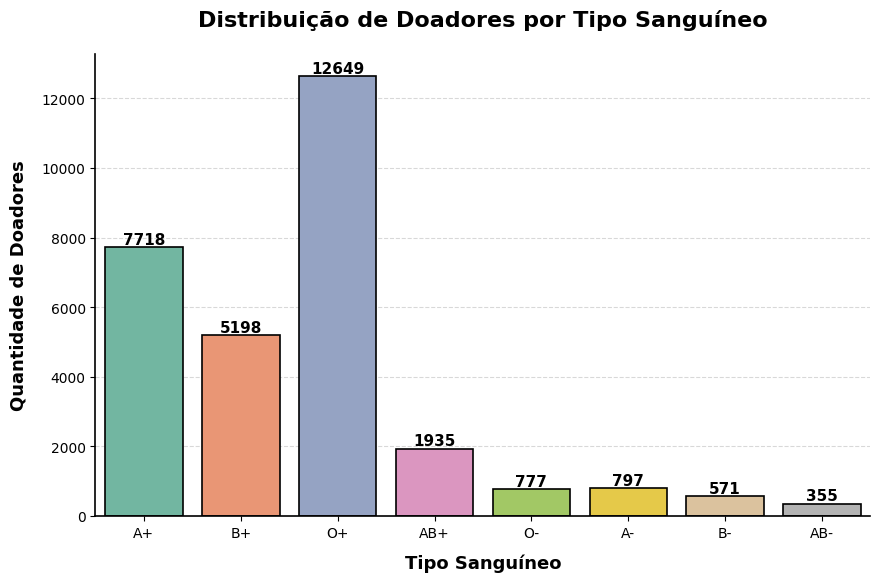

In [21]:
plt.style.use('default')
sns.set_palette("husl")
contagens = df['blood_type'].value_counts().sort_index()
plt.figure(figsize=(10, 6))

bars = sns.countplot(x='blood_type', data=df, hue='blood_type', palette='Set2',
                     edgecolor='black', linewidth=1.2)

for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='black')

plt.title('Distribuição de Doadores por Tipo Sanguíneo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Quantidade de Doadores', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)

O gráfico de barras acima mostra que para cada tipo sanguineo se somar todos os valores irão fechar 30000 instâncias, conforme o esperado e que não há informações nulas ou não preenchidas.

###Estatísticas descritivas
Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [22]:
df.describe()

,donor_id,age,is_rare_type,smoker,bmi,chronic_condition_flag,eligible_to_donate,donation_count_last_12m,is_regular_donor,years_since_first_donation,lifetime_donation_count,first_donation_year,recency_days,donor_age_at_first_donation,blood_type_country_prevalence,donation_propensity_score,donated_next_6m,next_6m_donation_count
count,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,45.13510,0.071967,0.240767,25.971250,0.135300,0.830500,0.765267,0.189500,8.249100,10.091033,2015.750900,1008.677000,36.886000,0.286317,33.795320,0.371133,0.537900
std,8660.398374,10.83432,0.258437,0.427556,3.983766,0.342049,0.375199,1.204609,0.391912,6.352128,17.313228,6.352128,1141.658289,10.478902,0.140478,20.880561,0.483116,0.820926
min,1.000000,18.00000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1989.000000,1.000000,18.000000,0.002220,0.000000,0.000000,0.000000
25%,7500.750000,37.00000,0.000000,0.000000,23.300000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,2012.000000,232.000000,29.000000,0.192480,21.300000,0.000000,0.000000
50%,15000.500000,45.00000,0.000000,0.000000,26.000000,0.000000,1.000000,0.000000,0.000000,7.000000,3.000000,2017.000000,554.000000,36.000000,0.287097,32.800000,0.000000,0.000000
75%,22500.250000,53.00000,0.000000,0.000000,28.700000,0.000000,1.000000,1.000000,0.000000,12.000000,8.000000,2021.000000,1394.000000,44.000000,0.400264,47.600000,1.000000,1.000000
max,30000.000000,69.00000,1.000000,1.000000,42.000000,1.000000,1.000000,5.000000,1.000000,35.000000,140.000000,2024.000000,6552.000000,68.000000,0.507883,89.200000,1.000000,3.000000


###Média
A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações, é sensível a valores extremos (outliers).

####Média hipótese 1
Aqui estará as informações de média para a primeira hipótese:
1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.


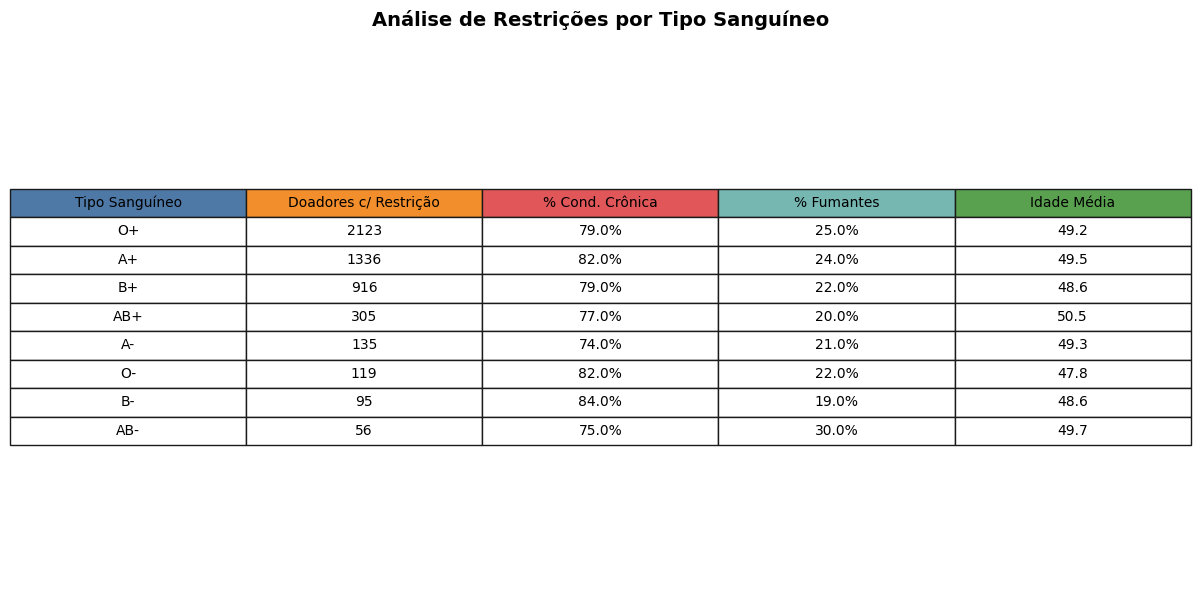

In [115]:
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
restricoes_por_tipo = df_com_restricao.groupby('blood_type').agg({
    'donor_id': 'count',
    'chronic_condition_flag': 'mean',
    'smoker': 'mean',
    'age': 'mean'
}).round(2)
restricoes_por_tipo.columns = ['Doadores_com_restricao', 'Pct_condicao_cronica', 'Pct_fumantes', 'Idade_media']
restricoes_por_tipo = restricoes_por_tipo.sort_values('Doadores_com_restricao', ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    tabela_data.append([
        tipo,
        int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao']),
        f"{restricoes_por_tipo.loc[tipo, 'Pct_condicao_cronica']*100:.1f}%",
        f"{restricoes_por_tipo.loc[tipo, 'Pct_fumantes']*100:.1f}%",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição', '% Cond. Crônica', '% Fumantes', 'Idade Média'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Análise de Restrições por Tipo Sanguíneo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

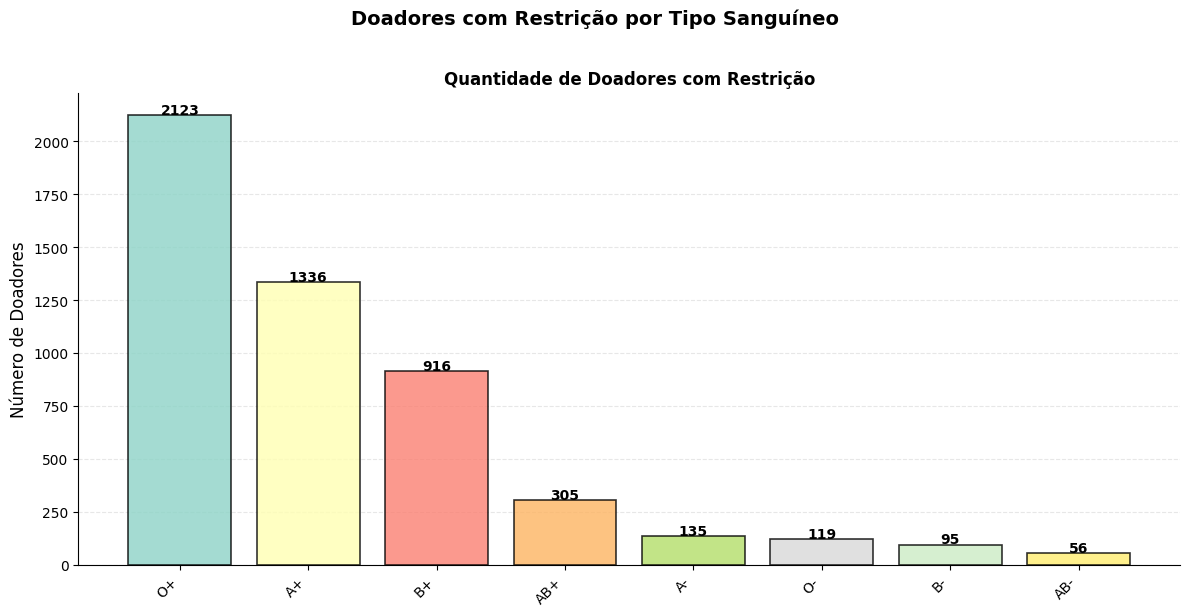

In [116]:
tipos = restricoes_por_tipo.index
doadores = restricoes_por_tipo['Doadores_com_restricao'].values
cores = plt.cm.Set3(np.linspace(0, 1, len(tipos)))
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Doadores com Restrição por Tipo Sanguíneo', fontsize=14, fontweight='bold', y=1.02)
bars = ax.bar(range(len(tipos)), doadores, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
for i, (bar, val) in enumerate(zip(bars, doadores)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{int(val)}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Número de Doadores', fontsize=12)
ax.set_title('Quantidade de Doadores com Restrição', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

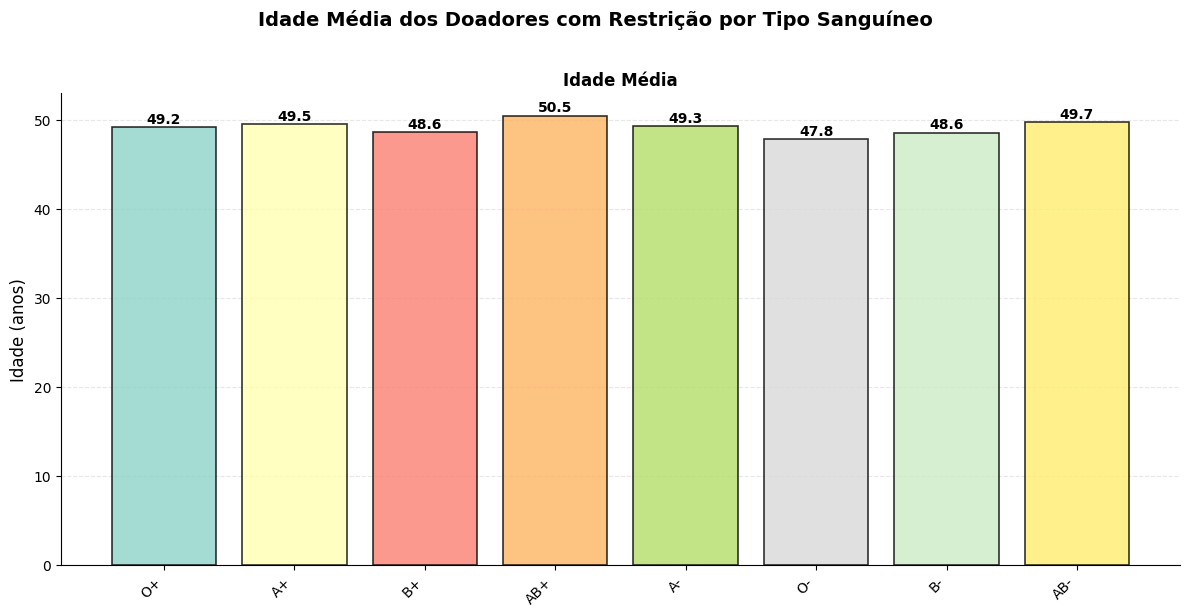

In [117]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Idade Média dos Doadores com Restrição por Tipo Sanguíneo', fontsize=14, fontweight='bold', y=1.02)
idades = restricoes_por_tipo['Idade_media'].values
bars = ax.bar(range(len(tipos)), idades, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
for i, (bar, val) in enumerate(zip(bars, idades)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Idade (anos)', fontsize=12)
ax.set_title('Idade Média', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

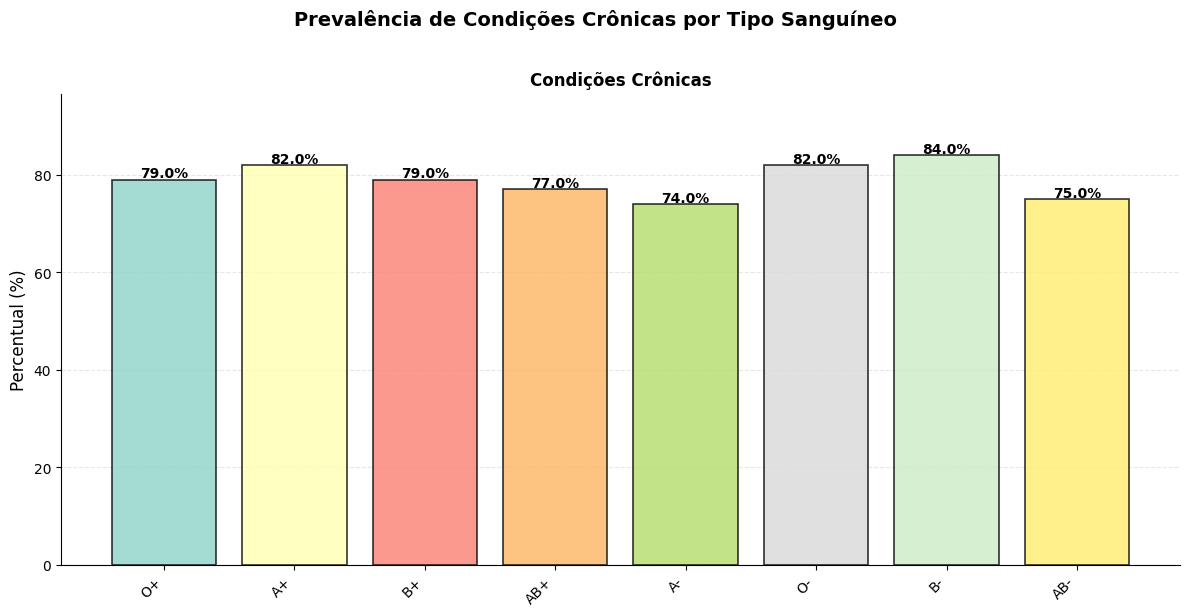

In [118]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Prevalência de Condições Crônicas por Tipo Sanguíneo', fontsize=14, fontweight='bold', y=1.02)
cond_cronica = restricoes_por_tipo['Pct_condicao_cronica'].values * 100
bars = ax.bar(range(len(tipos)), cond_cronica, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
for i, (bar, val) in enumerate(zip(bars, cond_cronica)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Condições Crônicas', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(cond_cronica) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

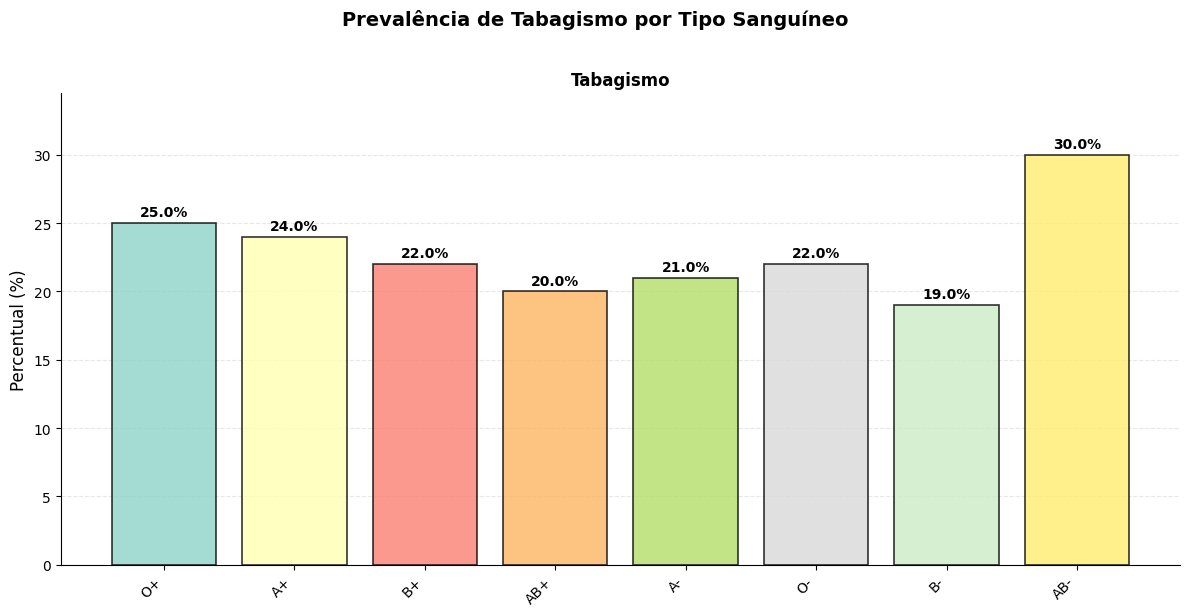

In [119]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Prevalência de Tabagismo por Tipo Sanguíneo', fontsize=14, fontweight='bold', y=1.02)
fumantes = restricoes_por_tipo['Pct_fumantes'].values * 100
bars = ax.bar(range(len(tipos)), fumantes, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
for i, (bar, val) in enumerate(zip(bars, fumantes)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Tabagismo', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(fumantes) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

####Média hipótese 2
Aqui estará as informações de média para a segunda hipótese:

2. Quantidade de doadores por sexo.


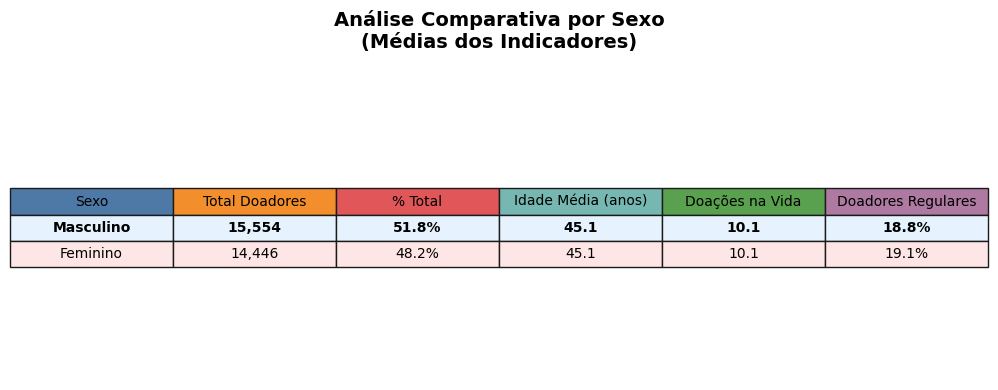

In [145]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
total = len(df)
estatisticas_media = pd.DataFrame({
    'Sexo': ['Masculino', 'Feminino'],
    'Total_Doadores': [len(df_masculino), len(df_feminino)],
    'Percentual': [len(df_masculino)/total*100, len(df_feminino)/total*100],
    'Idade_media': [df_masculino['age'].mean(), df_feminino['age'].mean()],
    'Doacoes_vida_media': [df_masculino['lifetime_donation_count'].mean(), df_feminino['lifetime_donation_count'].mean()],
    'Taxa_regular_media': [df_masculino['is_regular_donor'].mean()*100, df_feminino['is_regular_donor'].mean()*100]
})
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Masculino',
     f"{int(estatisticas_media.loc[0, 'Total_Doadores']):,}",
     f"{estatisticas_media.loc[0, 'Percentual']:.1f}%",
     f"{estatisticas_media.loc[0, 'Idade_media']:.1f}",
     f"{estatisticas_media.loc[0, 'Doacoes_vida_media']:.1f}",
     f"{estatisticas_media.loc[0, 'Taxa_regular_media']:.1f}%"],
    ['Feminino',
     f"{int(estatisticas_media.loc[1, 'Total_Doadores']):,}",
     f"{estatisticas_media.loc[1, 'Percentual']:.1f}%",
     f"{estatisticas_media.loc[1, 'Idade_media']:.1f}",
     f"{estatisticas_media.loc[1, 'Doacoes_vida_media']:.1f}",
     f"{estatisticas_media.loc[1, 'Taxa_regular_media']:.1f}%"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Sexo', 'Total Doadores', '% Total',
                             'Idade Média (anos)', 'Doações na Vida', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
for j in range(6):
    cell = tabela[(1, j)]
    cell.set_facecolor('#e6f3ff')
    cell.set_text_props(weight='bold')
for j in range(6):
    cell = tabela[(2, j)]
    cell.set_facecolor('#ffe6e6')
plt.title('Análise Comparativa por Sexo\n(Médias dos Indicadores)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

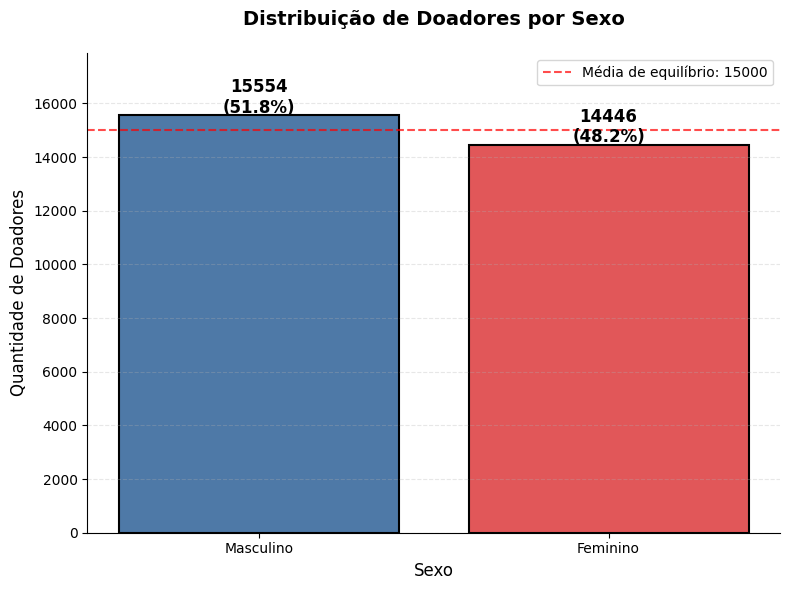

In [146]:
contagem_sexo = df['sex'].value_counts()
total = len(df)
contagem_sexo.index = ['Masculino', 'Feminino']
fig, ax = plt.subplots(figsize=(8, 6))
cores = ['#4e79a7', '#e15759']
bars = ax.bar(contagem_sexo.index, contagem_sexo.values, color=cores, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars, contagem_sexo.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Doadores', fontsize=12)
ax.set_xlabel('Sexo', fontsize=12)
ax.set_title('Distribuição de Doadores por Sexo', fontsize=14, fontweight='bold', pad=20)
media_equilibrio = total / 2
ax.axhline(y=media_equilibrio, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Média de equilíbrio: {media_equilibrio:.0f}')
ax.set_ylim(0, max(contagem_sexo.values) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

####Média hipótese 3
Aqui estará as informações de média para a terceira hipótese:

3. Doadores de sangue fumantes.

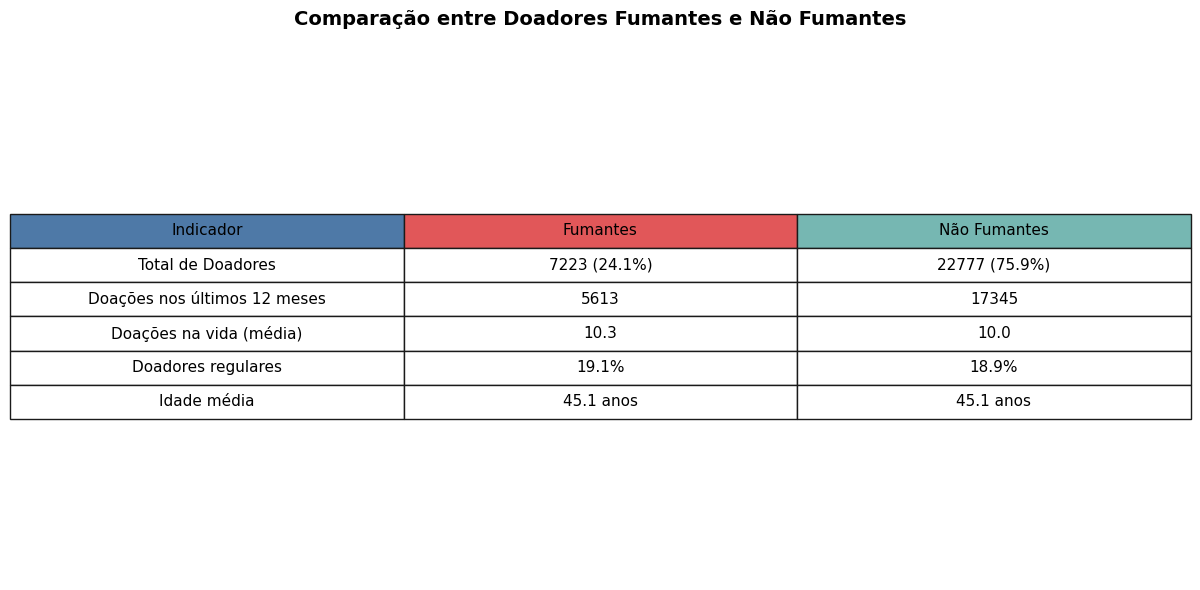

In [104]:
fumantes = df[df['smoker'] == 1]
nao_fumantes = df[df['smoker'] == 0]
dados_fumantes = {
    'Indicador': [
        'Total de Doadores',
        'Doações nos últimos 12 meses',
        'Doações na vida (média)',
        'Doadores regulares',
        'Idade média',
    ],
    'Fumantes': [
        f"{len(fumantes)} ({len(fumantes)/len(df)*100:.1f}%)",
        f"{fumantes['donation_count_last_12m'].sum():.0f}",
        f"{fumantes['lifetime_donation_count'].mean():.1f}",
        f"{fumantes['is_regular_donor'].mean()*100:.1f}%",
        f"{fumantes['age'].mean():.1f} anos"
    ],
    'Não Fumantes': [
        f"{len(nao_fumantes)} ({len(nao_fumantes)/len(df)*100:.1f}%)",
        f"{nao_fumantes['donation_count_last_12m'].sum():.0f}",
        f"{nao_fumantes['lifetime_donation_count'].mean():.1f}",
        f"{nao_fumantes['is_regular_donor'].mean()*100:.1f}%",
        f"{nao_fumantes['age'].mean():.1f} anos"
    ]
}
df_fumantes = pd.DataFrame(dados_fumantes)
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=df_fumantes.values,
                  colLabels=df_fumantes.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.8)
plt.title('Comparação entre Doadores Fumantes e Não Fumantes', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

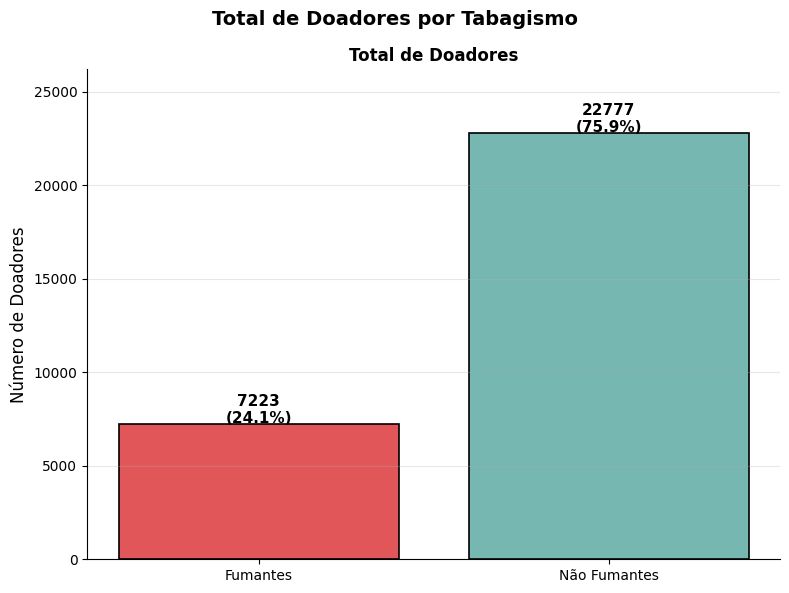

In [151]:
fumantes = df[df['smoker'] == 1]
nao_fumantes = df[df['smoker'] == 0]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Total de Doadores por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
categorias = ['Fumantes', 'Não Fumantes']
cores = ['#e15759', '#76b7b2']
totais = [len(fumantes), len(nao_fumantes)]
bars = ax.bar(categorias, totais, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, totais):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doadores', fontsize=12)
ax.set_title('Total de Doadores', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(totais) * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

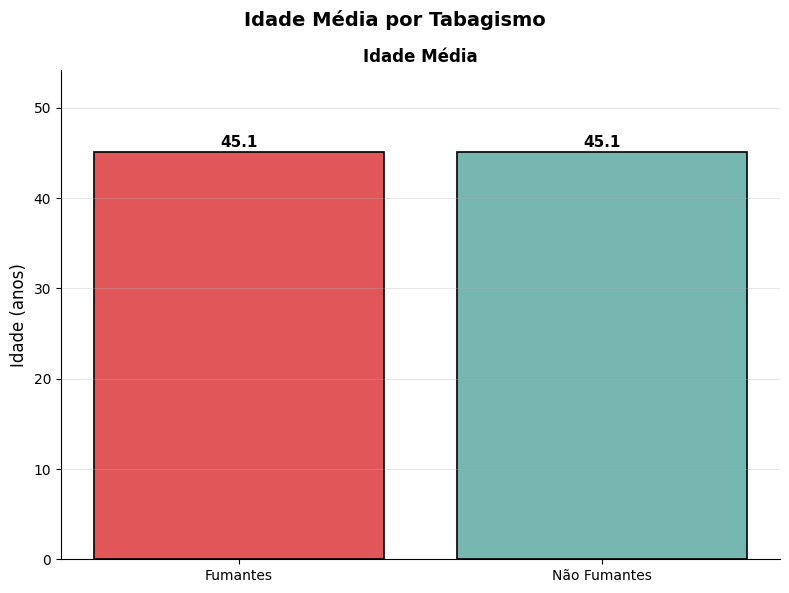

In [148]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Idade Média por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
idades = [fumantes['age'].mean(), nao_fumantes['age'].mean()]
bars = ax.bar(categorias, idades, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, idades):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Idade (anos)', fontsize=12)
ax.set_title('Idade Média', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(idades) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

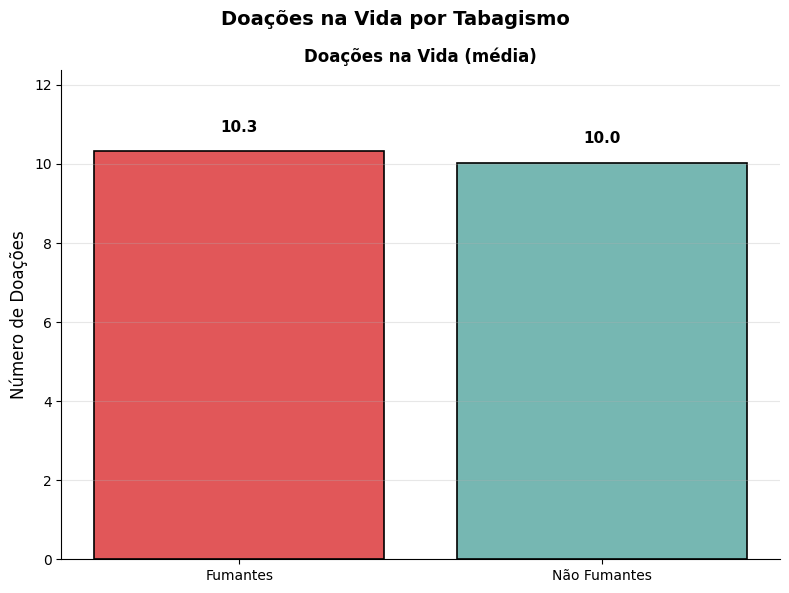

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doações na Vida por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
doacoes_vida = [fumantes['lifetime_donation_count'].mean(), nao_fumantes['lifetime_donation_count'].mean()]
bars = ax.bar(categorias, doacoes_vida, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, doacoes_vida):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doações', fontsize=12)
ax.set_title('Doações na Vida (média)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(doacoes_vida) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

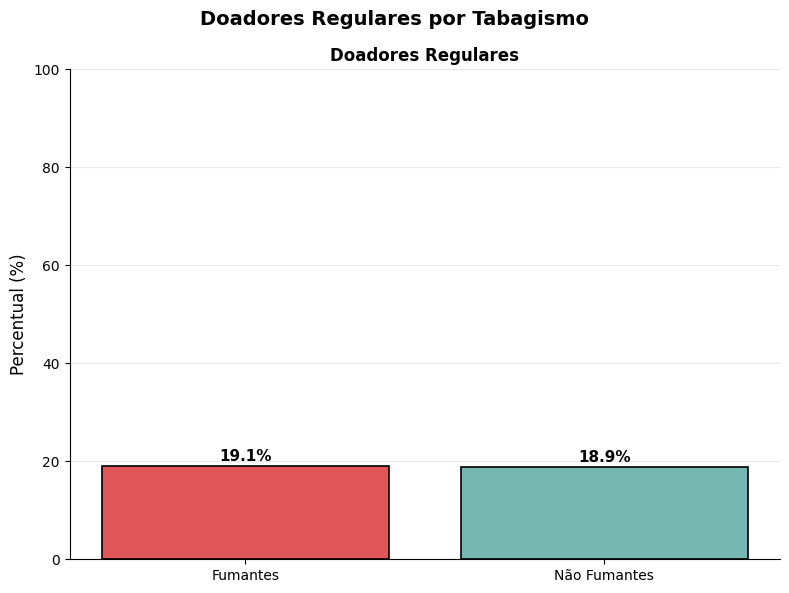

In [150]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doadores Regulares por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
regularidade = [fumantes['is_regular_donor'].mean()*100, nao_fumantes['is_regular_donor'].mean()*100]
bars = ax.bar(categorias, regularidade, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, regularidade):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Doadores Regulares', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

####Desvio padrão hipótese 1
Aqui estará as informações de desvio padrão para a primeira hipótese:
1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.


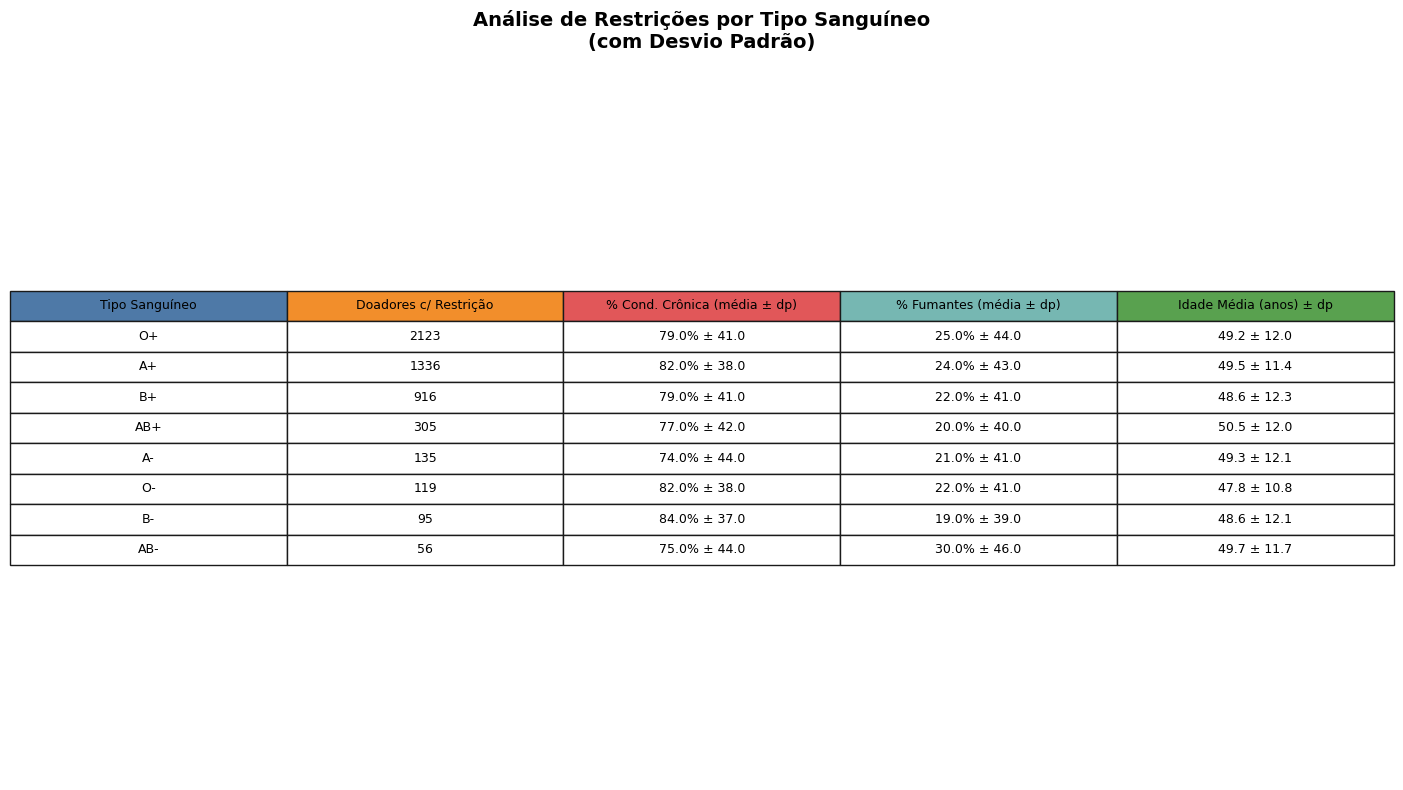

In [87]:
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
restricoes_por_tipo = df_com_restricao.groupby('blood_type').agg({
    'donor_id': 'count',
    'chronic_condition_flag': ['mean', 'std'],
    'smoker': ['mean', 'std'],
    'age': ['mean', 'std']
}).round(2)
restricoes_por_tipo.columns = [
    'Doadores_com_restricao',
    'Cond_cronica_media', 'Cond_cronica_desvio',
    'Fumantes_media', 'Fumantes_desvio',
    'Idade_media', 'Idade_desvio'
]
restricoes_por_tipo = restricoes_por_tipo.sort_values('Doadores_com_restricao', ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    tabela_data.append([
        tipo,
        int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao']),
        f"{restricoes_por_tipo.loc[tipo, 'Cond_cronica_media']*100:.1f}% ± {restricoes_por_tipo.loc[tipo, 'Cond_cronica_desvio']*100:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Fumantes_media']*100:.1f}% ± {restricoes_por_tipo.loc[tipo, 'Fumantes_desvio']*100:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f} ± {restricoes_por_tipo.loc[tipo, 'Idade_desvio']:.1f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição',
                             '% Cond. Crônica (média ± dp)',
                             '% Fumantes (média ± dp)',
                             'Idade Média (anos) ± dp'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.6)
plt.title('Análise de Restrições por Tipo Sanguíneo\n(com Desvio Padrão)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

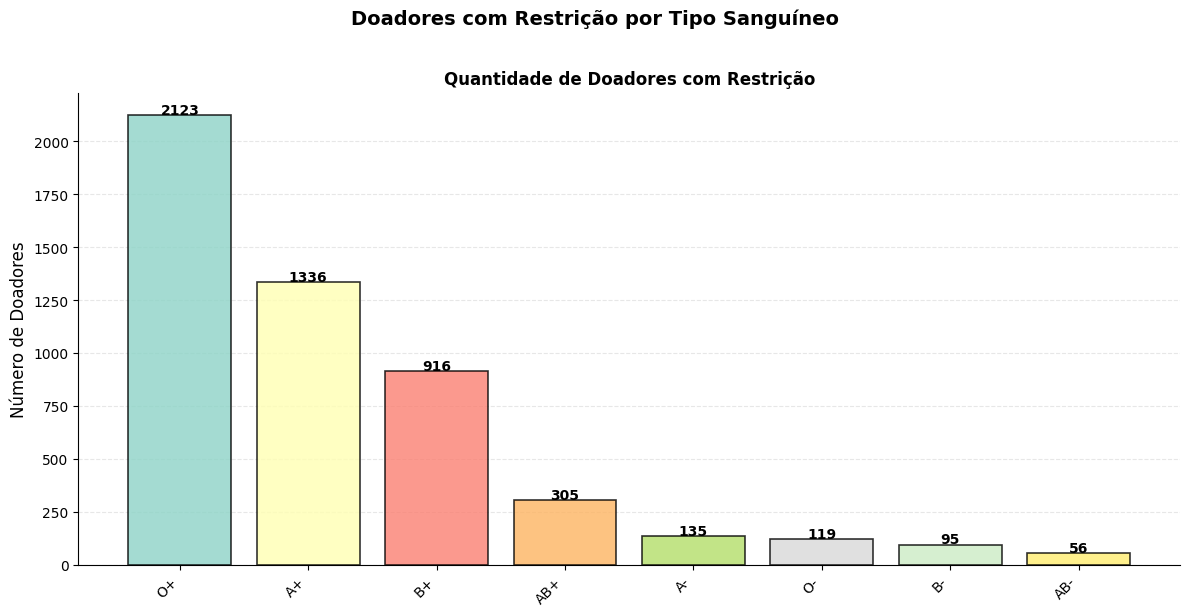

In [96]:
tipos = restricoes_por_tipo.index
doadores = restricoes_por_tipo['Doadores_com_restricao'].values
cores = plt.cm.Set3(np.linspace(0, 1, len(tipos)))
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Doadores com Restrição por Tipo Sanguíneo',
             fontsize=14, fontweight='bold', y=1.02)
bars = ax.bar(range(len(tipos)), doadores, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
for i, (bar, val) in enumerate(zip(bars, doadores)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{int(val)}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Número de Doadores', fontsize=12)
ax.set_title('Quantidade de Doadores com Restrição', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

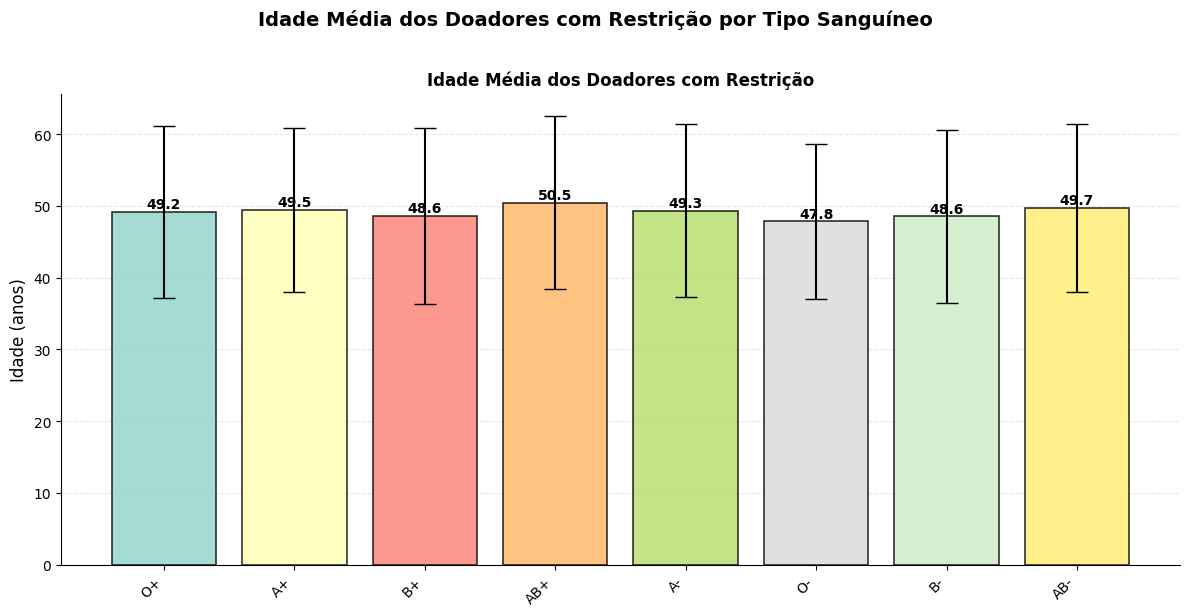

In [97]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Idade Média dos Doadores com Restrição por Tipo Sanguíneo',
             fontsize=14, fontweight='bold', y=1.02)
idades = restricoes_por_tipo['Idade_media'].values
desvios_idade = restricoes_por_tipo['Idade_desvio'].values
bars = ax.bar(range(len(tipos)), idades, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.errorbar(range(len(tipos)), idades, yerr=desvios_idade, fmt='none',
            color='black', capsize=8, linewidth=1.5)
for i, (bar, val) in enumerate(zip(bars, idades)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Idade (anos)', fontsize=12)
ax.set_title('Idade Média dos Doadores com Restrição', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

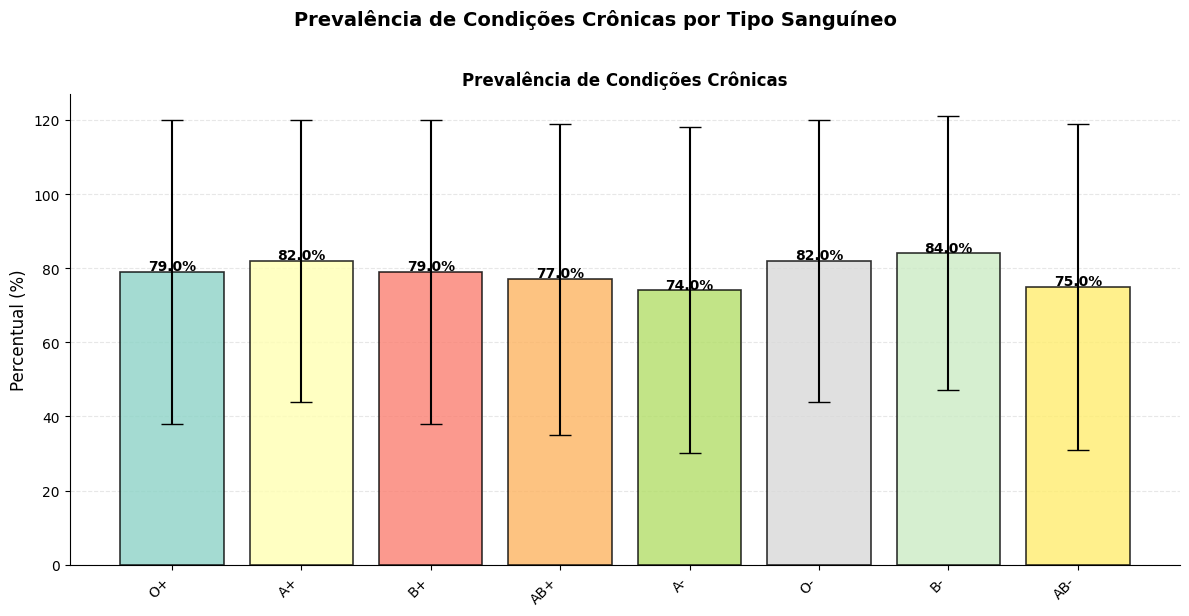

In [98]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Prevalência de Condições Crônicas por Tipo Sanguíneo',
             fontsize=14, fontweight='bold', y=1.02)
cond_cronica = restricoes_por_tipo['Cond_cronica_media'].values * 100
desvios_cond = restricoes_por_tipo['Cond_cronica_desvio'].values * 100
bars = ax.bar(range(len(tipos)), cond_cronica, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.errorbar(range(len(tipos)), cond_cronica, yerr=desvios_cond, fmt='none',
            color='black', capsize=8, linewidth=1.5)
for i, (bar, val) in enumerate(zip(bars, cond_cronica)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Prevalência de Condições Crônicas', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

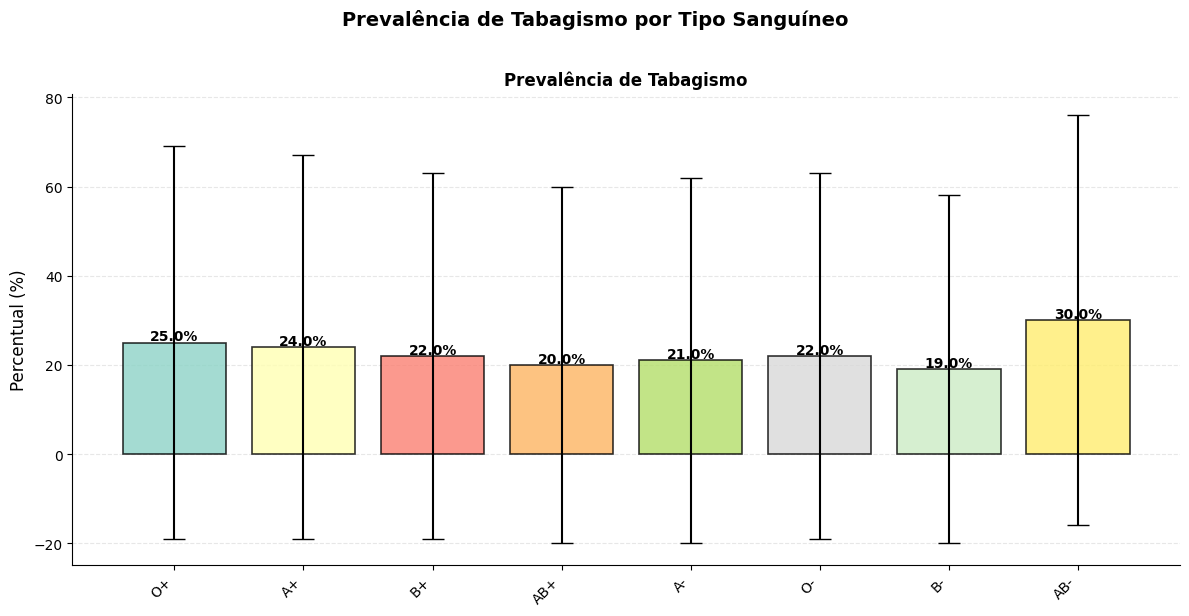

In [99]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Prevalência de Tabagismo por Tipo Sanguíneo',
             fontsize=14, fontweight='bold', y=1.02)
fumantes = restricoes_por_tipo['Fumantes_media'].values * 100
desvios_fum = restricoes_por_tipo['Fumantes_desvio'].values * 100
bars = ax.bar(range(len(tipos)), fumantes, color=cores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.errorbar(range(len(tipos)), fumantes, yerr=desvios_fum, fmt='none',
            color='black', capsize=8, linewidth=1.5)
for i, (bar, val) in enumerate(zip(bars, fumantes)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Prevalência de Tabagismo', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

####Desvio padrão hipótese 2
Aqui estará as informações de desvio padrão para a segunda hipótese:

2. Quantidade de doadores por sexo.

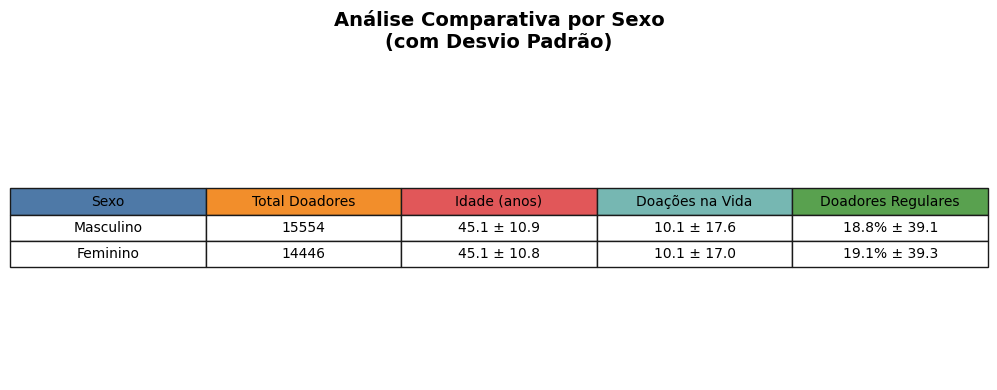

In [84]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
estatisticas_sexo = pd.DataFrame({
    'Sexo': ['Masculino', 'Feminino'],

    # 1. Total de Doadores
    'Total_Doadores': [len(df_masculino), len(df_feminino)],

    # 2. Idade Média
    'Idade_media': [df_masculino['age'].mean(), df_feminino['age'].mean()],
    'Idade_desvio': [df_masculino['age'].std(), df_feminino['age'].std()],

    # 3. Doações na Vida
    'Doacoes_vida_media': [df_masculino['lifetime_donation_count'].mean(), df_feminino['lifetime_donation_count'].mean()],
    'Doacoes_vida_desvio': [df_masculino['lifetime_donation_count'].std(), df_feminino['lifetime_donation_count'].std()],

    # 4. Doadores Regulares
    'Taxa_regular_media': [df_masculino['is_regular_donor'].mean()*100, df_feminino['is_regular_donor'].mean()*100],
    'Taxa_regular_desvio': [df_masculino['is_regular_donor'].std()*100, df_feminino['is_regular_donor'].std()*100]
})
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Masculino',
     int(estatisticas_sexo.loc[0, 'Total_Doadores']),
     f"{estatisticas_sexo.loc[0, 'Idade_media']:.1f} ± {estatisticas_sexo.loc[0, 'Idade_desvio']:.1f}",
     f"{estatisticas_sexo.loc[0, 'Doacoes_vida_media']:.1f} ± {estatisticas_sexo.loc[0, 'Doacoes_vida_desvio']:.1f}",
     f"{estatisticas_sexo.loc[0, 'Taxa_regular_media']:.1f}% ± {estatisticas_sexo.loc[0, 'Taxa_regular_desvio']:.1f}"],
    ['Feminino',
     int(estatisticas_sexo.loc[1, 'Total_Doadores']),
     f"{estatisticas_sexo.loc[1, 'Idade_media']:.1f} ± {estatisticas_sexo.loc[1, 'Idade_desvio']:.1f}",
     f"{estatisticas_sexo.loc[1, 'Doacoes_vida_media']:.1f} ± {estatisticas_sexo.loc[1, 'Doacoes_vida_desvio']:.1f}",
     f"{estatisticas_sexo.loc[1, 'Taxa_regular_media']:.1f}% ± {estatisticas_sexo.loc[1, 'Taxa_regular_desvio']:.1f}"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Sexo', 'Total Doadores', 'Idade (anos)',
                             'Doações na Vida', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise Comparativa por Sexo\n(com Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

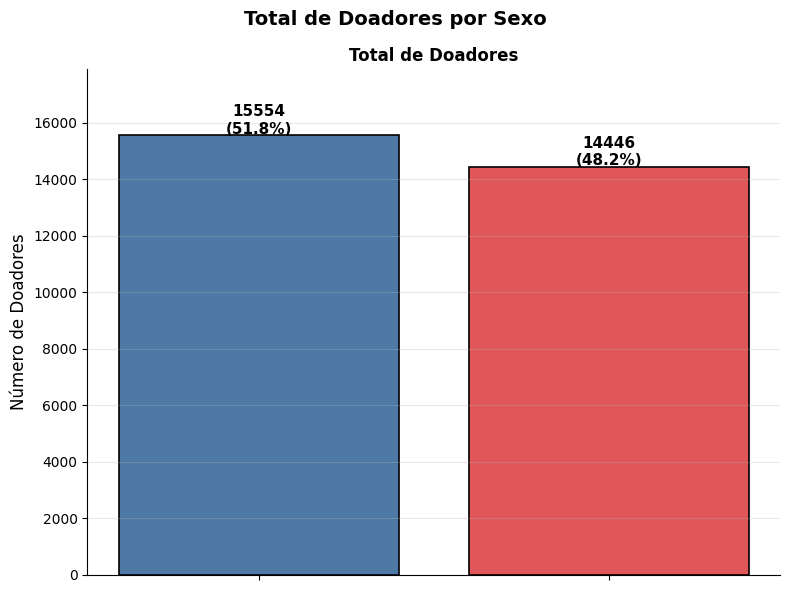

In [152]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
total = len(df)
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Total de Doadores por Sexo', fontsize=14, fontweight='bold', y=0.98)
sexos = ['Masculino', 'Feminino']
cores = ['#4e79a7', '#e15759']
totais = [len(df_masculino), len(df_feminino)]
bars = ax.bar(sexos, totais, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, totais):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doadores', fontsize=12)
ax.set_title('Total de Doadores', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(totais) * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

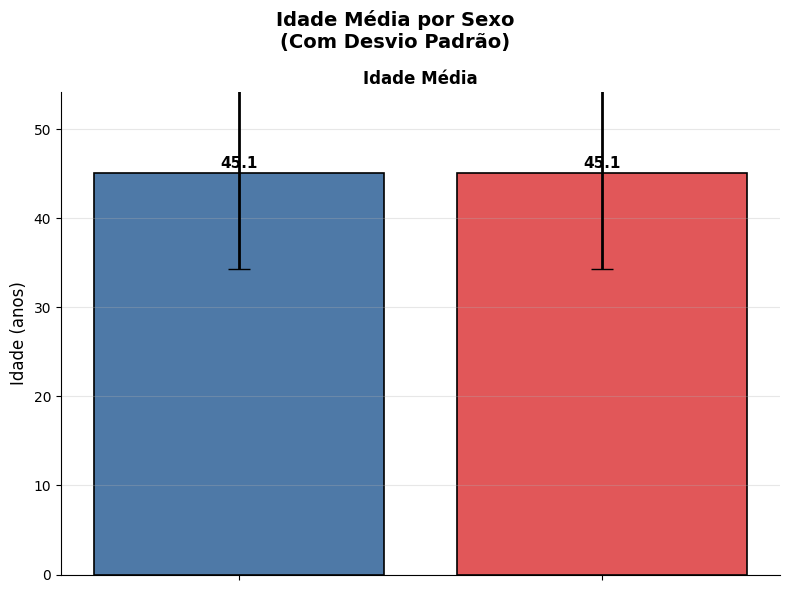

In [153]:
idade_media_masc = df_masculino['age'].mean()
idade_media_fem = df_feminino['age'].mean()
idade_desvio_masc = df_masculino['age'].std()
idade_desvio_fem = df_feminino['age'].std()
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Idade Média por Sexo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
idades = [idade_media_masc, idade_media_fem]
desvios_idade = [idade_desvio_masc, idade_desvio_fem]
bars = ax.bar(sexos, idades, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(sexos, idades, yerr=desvios_idade, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, idades):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Idade (anos)', fontsize=12)
ax.set_title('Idade Média', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(idades) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

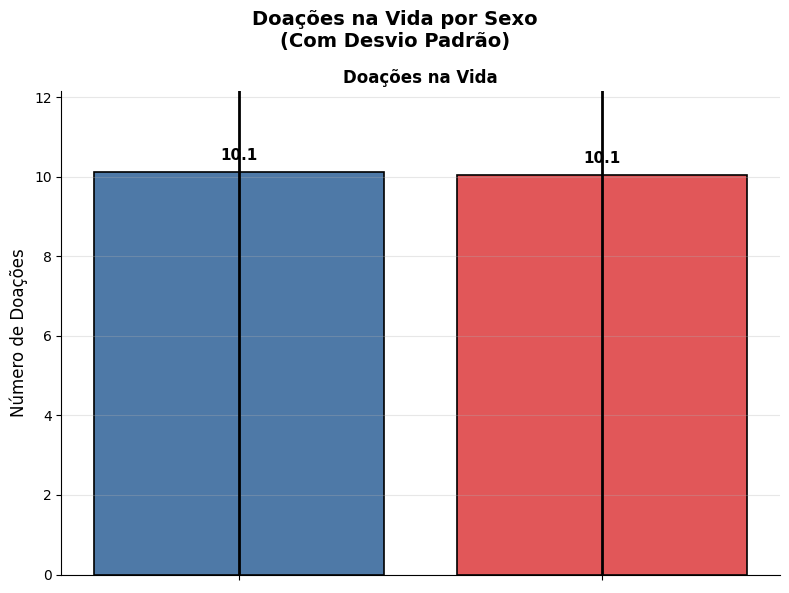

In [154]:
doacoes_media_masc = df_masculino['lifetime_donation_count'].mean()
doacoes_media_fem = df_feminino['lifetime_donation_count'].mean()
doacoes_desvio_masc = df_masculino['lifetime_donation_count'].std()
doacoes_desvio_fem = df_feminino['lifetime_donation_count'].std()
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doações na Vida por Sexo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
doacoes_vida = [doacoes_media_masc, doacoes_media_fem]
desvios_vida = [doacoes_desvio_masc, doacoes_desvio_fem]
bars = ax.bar(sexos, doacoes_vida, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(sexos, doacoes_vida, yerr=desvios_vida, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, doacoes_vida):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doações', fontsize=12)
ax.set_title('Doações na Vida', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(doacoes_vida) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

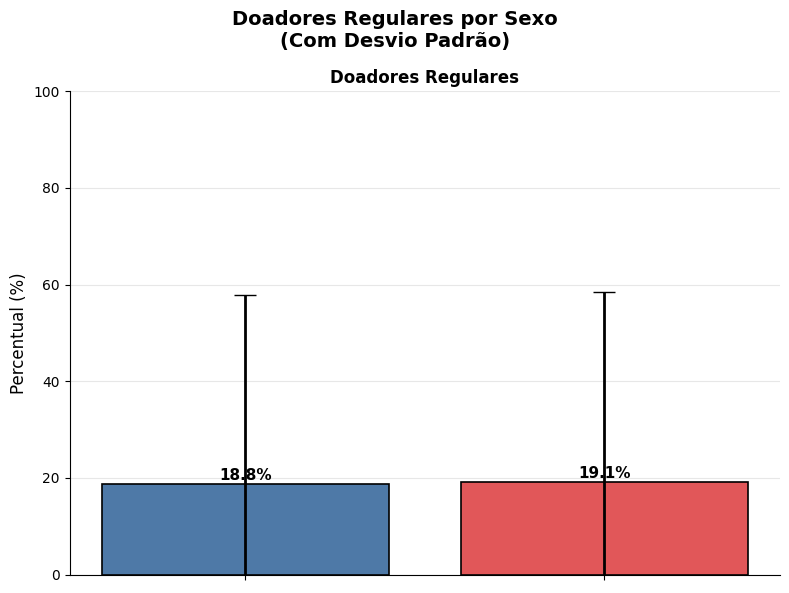

In [155]:
regulares_media_masc = df_masculino['is_regular_donor'].mean() * 100
regulares_media_fem = df_feminino['is_regular_donor'].mean() * 100
regulares_desvio_masc = df_masculino['is_regular_donor'].std() * 100
regulares_desvio_fem = df_feminino['is_regular_donor'].std() * 100
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doadores Regulares por Sexo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
regulares = [regulares_media_masc, regulares_media_fem]
desvios_reg = [regulares_desvio_masc, regulares_desvio_fem]
bars = ax.bar(sexos, regulares, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(sexos, regulares, yerr=desvios_reg, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, regulares):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Doadores Regulares', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

####Desvio padrão hipótese 3
Aqui estará as informações de desvio padrão para a terceira hipótese:

3. Doadores de sangue fumantes.

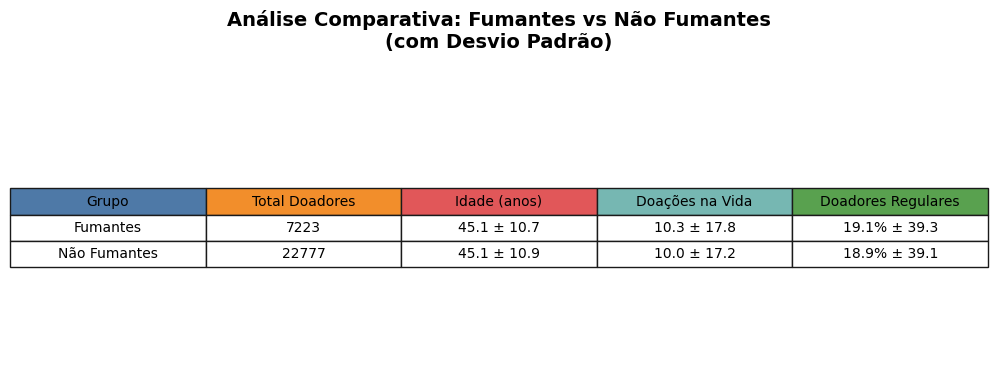

In [81]:
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
estatisticas_fumantes = pd.DataFrame({
    'Grupo': ['Fumantes', 'Não Fumantes'],

    # 1. Total de Doadores
    'Total_Doadores': [len(df_fumantes), len(df_nao_fumantes)],

    # 2. Idade Média
    'Idade_media': [df_fumantes['age'].mean(), df_nao_fumantes['age'].mean()],
    'Idade_desvio': [df_fumantes['age'].std(), df_nao_fumantes['age'].std()],

    # 3. Doações na Vida
    'Doacoes_vida_media': [df_fumantes['lifetime_donation_count'].mean(), df_nao_fumantes['lifetime_donation_count'].mean()],
    'Doacoes_vida_desvio': [df_fumantes['lifetime_donation_count'].std(), df_nao_fumantes['lifetime_donation_count'].std()],

    # 4. Doadores Regulares
    'Taxa_regular_media': [df_fumantes['is_regular_donor'].mean()*100, df_nao_fumantes['is_regular_donor'].mean()*100],
    'Taxa_regular_desvio': [df_fumantes['is_regular_donor'].std()*100, df_nao_fumantes['is_regular_donor'].std()*100]
})
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Fumantes',
     int(estatisticas_fumantes.loc[0, 'Total_Doadores']),
     f"{estatisticas_fumantes.loc[0, 'Idade_media']:.1f} ± {estatisticas_fumantes.loc[0, 'Idade_desvio']:.1f}",
     f"{estatisticas_fumantes.loc[0, 'Doacoes_vida_media']:.1f} ± {estatisticas_fumantes.loc[0, 'Doacoes_vida_desvio']:.1f}",
     f"{estatisticas_fumantes.loc[0, 'Taxa_regular_media']:.1f}% ± {estatisticas_fumantes.loc[0, 'Taxa_regular_desvio']:.1f}"],
    ['Não Fumantes',
     int(estatisticas_fumantes.loc[1, 'Total_Doadores']),
     f"{estatisticas_fumantes.loc[1, 'Idade_media']:.1f} ± {estatisticas_fumantes.loc[1, 'Idade_desvio']:.1f}",
     f"{estatisticas_fumantes.loc[1, 'Doacoes_vida_media']:.1f} ± {estatisticas_fumantes.loc[1, 'Doacoes_vida_desvio']:.1f}",
     f"{estatisticas_fumantes.loc[1, 'Taxa_regular_media']:.1f}% ± {estatisticas_fumantes.loc[1, 'Taxa_regular_desvio']:.1f}"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Grupo', 'Total Doadores', 'Idade (anos)',
                             'Doações na Vida', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise Comparativa: Fumantes vs Não Fumantes\n(com Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

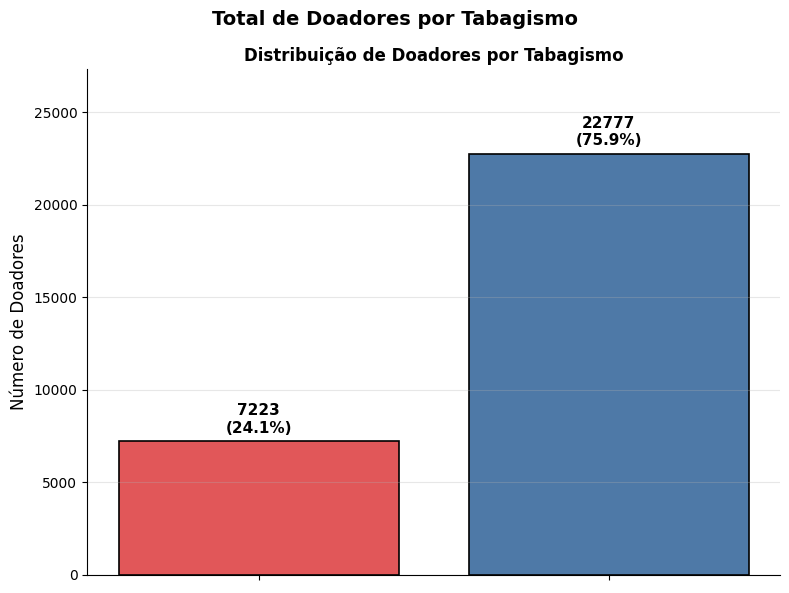

In [156]:
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
total = len(df)
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Total de Doadores por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
grupos = ['Fumantes', 'Não Fumantes']
cores = ['#e15759', '#4e79a7']
totais = [len(df_fumantes), len(df_nao_fumantes)]
bars = ax.bar(grupos, totais, color=cores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, totais):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(totais) * 0.02),
            f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doadores', fontsize=12)
ax.set_title('Distribuição de Doadores por Tabagismo', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(totais) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

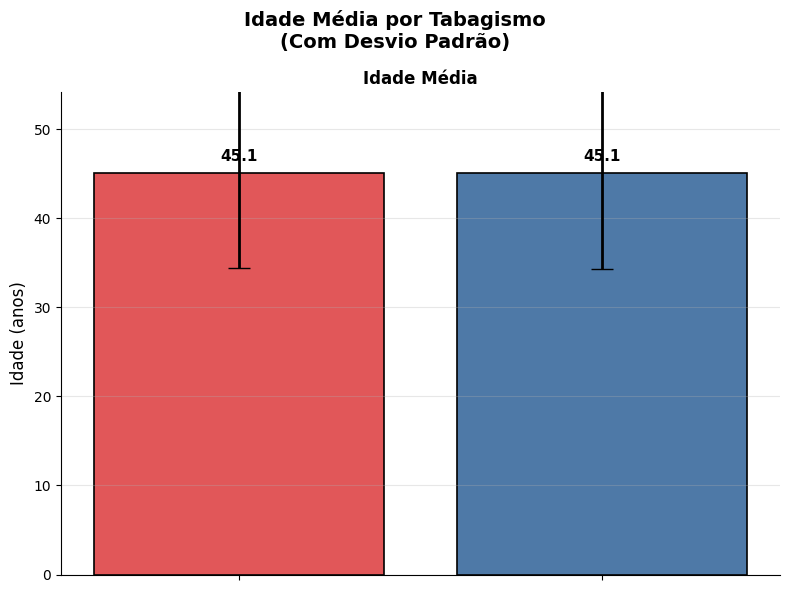

In [157]:
idade_media_fum = df_fumantes['age'].mean()
idade_media_naofum = df_nao_fumantes['age'].mean()
idade_desvio_fum = df_fumantes['age'].std()
idade_desvio_naofum = df_nao_fumantes['age'].std()
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Idade Média por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
idades = [idade_media_fum, idade_media_naofum]
desvios_idade = [idade_desvio_fum, idade_desvio_naofum]
bars = ax.bar(grupos, idades, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(grupos, idades, yerr=desvios_idade, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, idades):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(idades) * 0.03),
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Idade (anos)', fontsize=12)
ax.set_title('Idade Média', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(idades) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

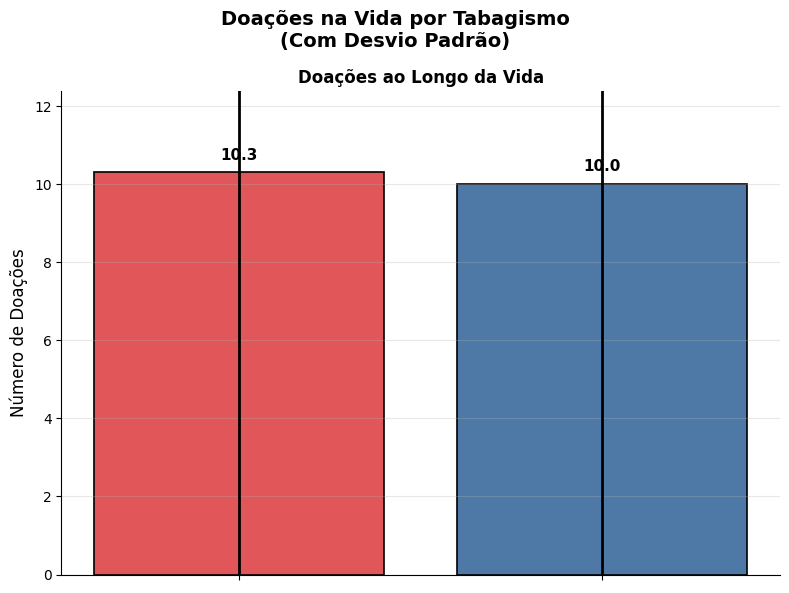

In [158]:
doacoes_media_fum = df_fumantes['lifetime_donation_count'].mean()
doacoes_media_naofum = df_nao_fumantes['lifetime_donation_count'].mean()
doacoes_desvio_fum = df_fumantes['lifetime_donation_count'].std()
doacoes_desvio_naofum = df_nao_fumantes['lifetime_donation_count'].std()
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doações na Vida por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
doacoes_vida = [doacoes_media_fum, doacoes_media_naofum]
desvios_vida = [doacoes_desvio_fum, doacoes_desvio_naofum]
bars = ax.bar(grupos, doacoes_vida, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(grupos, doacoes_vida, yerr=desvios_vida, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, doacoes_vida):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(doacoes_vida) * 0.03),
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Doações', fontsize=12)
ax.set_title('Doações ao Longo da Vida', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(doacoes_vida) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

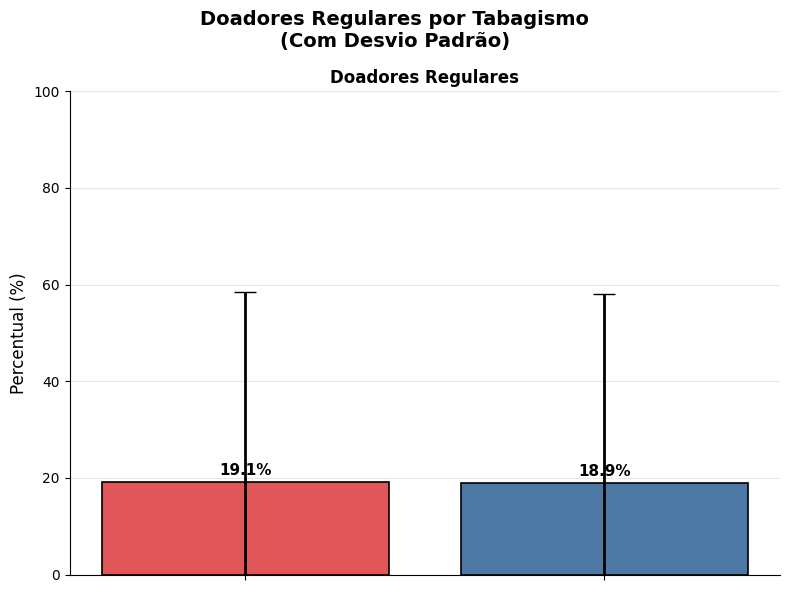

In [159]:
regulares_media_fum = df_fumantes['is_regular_donor'].mean() * 100
regulares_media_naofum = df_nao_fumantes['is_regular_donor'].mean() * 100
regulares_desvio_fum = df_fumantes['is_regular_donor'].std() * 100
regulares_desvio_naofum = df_nao_fumantes['is_regular_donor'].std() * 100
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doadores Regulares por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
regulares = [regulares_media_fum, regulares_media_naofum]
desvios_reg = [regulares_desvio_fum, regulares_desvio_naofum]
bars = ax.bar(grupos, regulares, color=cores, edgecolor='black', linewidth=1.2)
ax.errorbar(grupos, regulares, yerr=desvios_reg, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, regulares):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_title('Doadores Regulares', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

### Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

####Histograma hipótese 1
Aqui estará as informações de histograma para a primeira hipótese:

1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

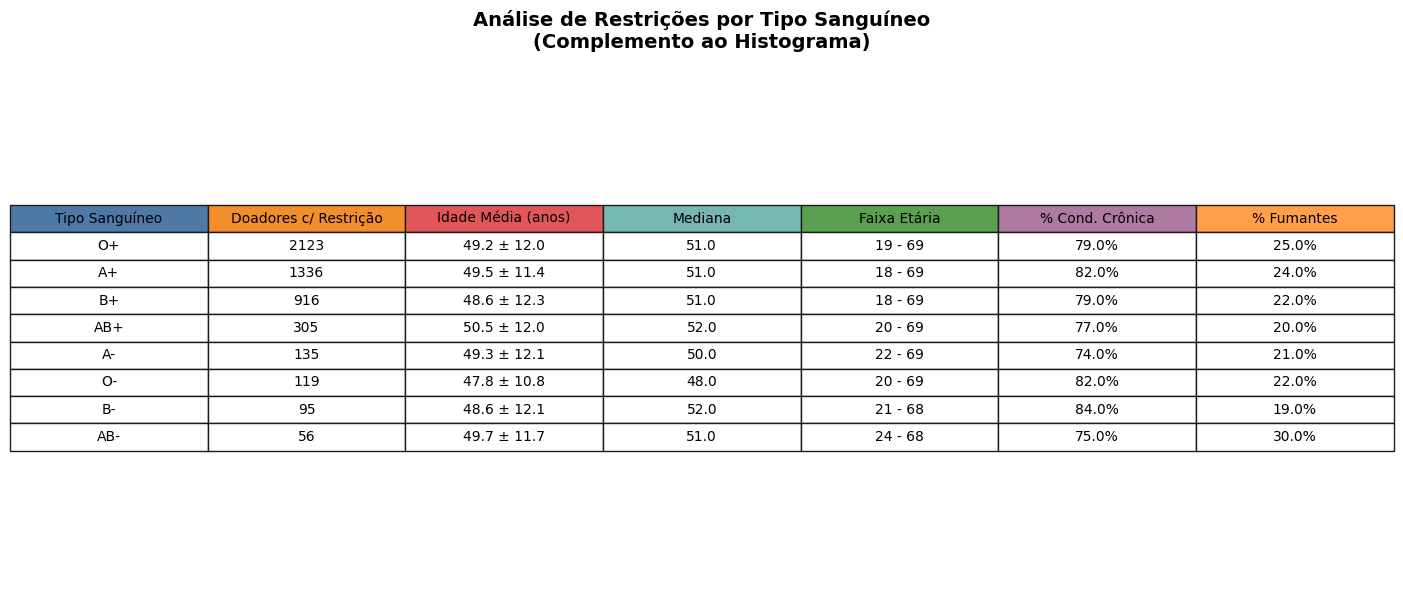

In [164]:
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
estatisticas_hip1 = df_com_restricao.groupby('blood_type').agg({
    'donor_id': 'count',
    'age': ['mean', 'std', 'median', 'min', 'max'],
    'chronic_condition_flag': 'mean',
    'smoker': 'mean'
}).round(2)
estatisticas_hip1.columns = [
    'Total_Restritos',
    'Idade_Media', 'Idade_Desvio', 'Idade_Mediana', 'Idade_Min', 'Idade_Max',
    'Pct_Cond_Cronica',
    'Pct_Fumantes'
]
estatisticas_hip1['Pct_Cond_Cronica'] = estatisticas_hip1['Pct_Cond_Cronica'] * 100
estatisticas_hip1['Pct_Fumantes'] = estatisticas_hip1['Pct_Fumantes'] * 100
estatisticas_hip1 = estatisticas_hip1.sort_values('Total_Restritos', ascending=False)
fig, ax = plt.subplots(figsize=(14, max(6, len(estatisticas_hip1) * 0.5)))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in estatisticas_hip1.index:
    tabela_data.append([
        tipo,
        f"{int(estatisticas_hip1.loc[tipo, 'Total_Restritos'])}",
        f"{estatisticas_hip1.loc[tipo, 'Idade_Media']:.1f} ± {estatisticas_hip1.loc[tipo, 'Idade_Desvio']:.1f}",
        f"{estatisticas_hip1.loc[tipo, 'Idade_Mediana']:.1f}",
        f"{estatisticas_hip1.loc[tipo, 'Idade_Min']:.0f} - {estatisticas_hip1.loc[tipo, 'Idade_Max']:.0f}",
        f"{estatisticas_hip1.loc[tipo, 'Pct_Cond_Cronica']:.1f}%",
        f"{estatisticas_hip1.loc[tipo, 'Pct_Fumantes']:.1f}%"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição',
                             'Idade Média (anos)', 'Mediana', 'Faixa Etária',
                             '% Cond. Crônica', '% Fumantes'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Análise de Restrições por Tipo Sanguíneo\n(Complemento ao Histograma)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

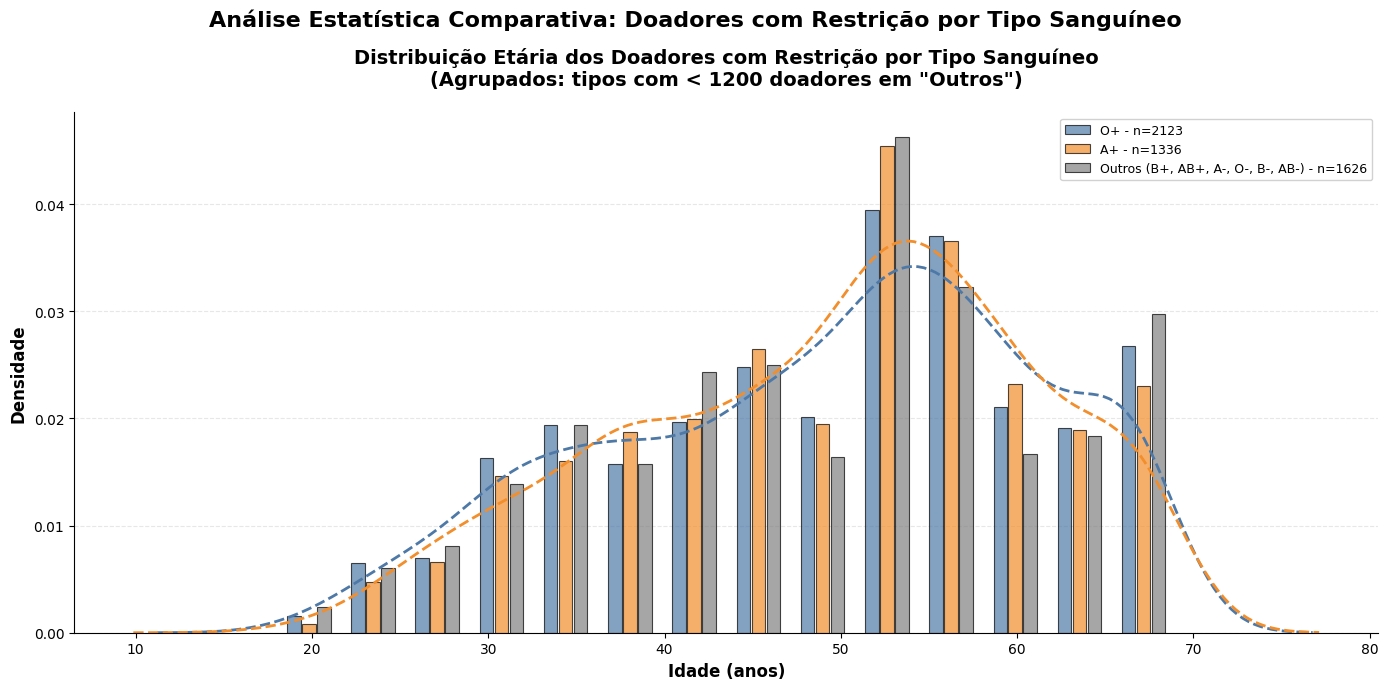

In [59]:
plt.style.use('default')
sns.set_palette("husl")
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
contagem = df_com_restricao['blood_type'].value_counts()
limitar = 1200
tipos_principais = contagem[contagem >= limitar].index.tolist()
tipos_secundarios = contagem[contagem < limitar].index.tolist()
df_agrupado = df_com_restricao.copy()
if tipos_secundarios:
    df_agrupado.loc[df_agrupado['blood_type'].isin(tipos_secundarios), 'blood_type'] = 'Outros'
    tipos_agrupados_str = ', '.join(tipos_secundarios)
else:
    tipos_agrupados_str = ""
ordem_tipos = tipos_principais + (['Outros'] if tipos_secundarios else [])
bins = np.linspace(df['age'].min(), df['age'].max(), 15)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]
hist_data = {}
for tipo in ordem_tipos:
    df_tipo = df_agrupado[df_agrupado['blood_type'] == tipo]
    if len(df_tipo) > 0:
        hist, _ = np.histogram(df_tipo['age'], bins=bins, density=True)
        hist_data[tipo] = hist
cores_principais = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1']
cores = cores_principais[:len(tipos_principais)] + (['#808080'] if tipos_secundarios else [])
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Análise Estatística Comparativa: Doadores com Restrição por Tipo Sanguíneo',
             fontsize=16, fontweight='bold', y=0.98)
n_grupos = len(ordem_tipos)
largura_barra = bin_width * 0.7 / n_grupos
offset = bin_width * 0.15
for i, tipo in enumerate(ordem_tipos):
    if tipo in hist_data:
        posicoes = bin_centers + (i - n_grupos/2 + 0.5) * largura_barra
        if tipo == 'Outros' and tipos_secundarios:
            label = f'Outros ({tipos_agrupados_str}) - n={len(df_agrupado[df_agrupado["blood_type"] == tipo])}'
        else:
            label = f'{tipo} - n={len(df_agrupado[df_agrupado["blood_type"] == tipo])}'
        ax1.bar(posicoes, hist_data[tipo], width=largura_barra * 0.9,
                alpha=0.7, color=cores[i % len(cores)],
                edgecolor='black', linewidth=0.8, label=label)
for i, tipo in enumerate(ordem_tipos):
    if tipo != 'Outros' and tipo in hist_data:
        df_tipo = df_agrupado[df_agrupado['blood_type'] == tipo]
        if len(df_tipo) > 0:
            sns.kdeplot(df_tipo['age'], color=cores[i % len(cores)],
                       linewidth=2, ax=ax1, linestyle='--')
ax1.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax1.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax1.set_title(f'Distribuição Etária dos Doadores com Restrição por Tipo Sanguíneo\n(Agrupados: tipos com < {limitar} doadores em "Outros")',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

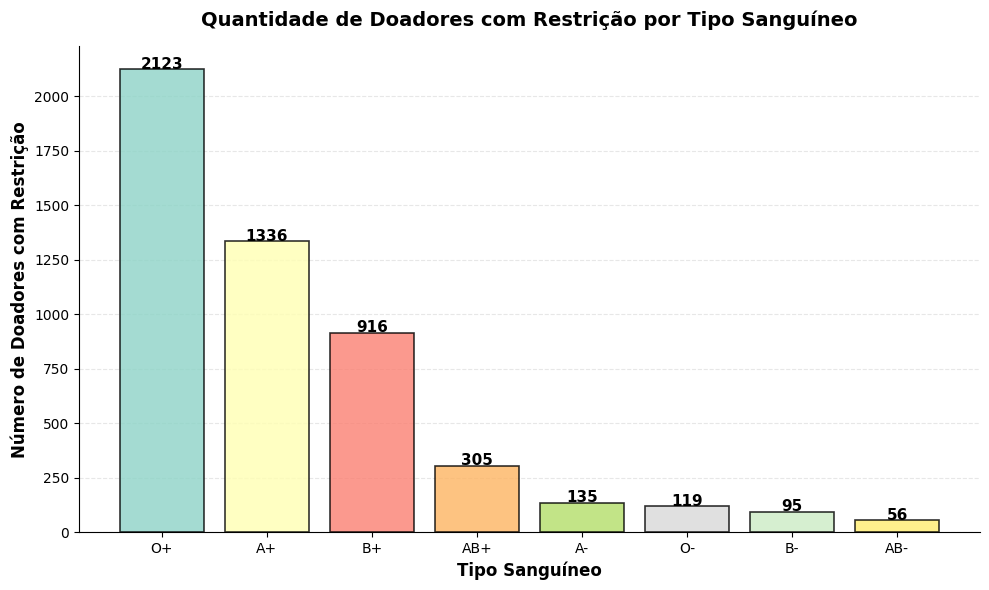

In [50]:
fig, ax2 = plt.subplots(figsize=(10, 6))
contagem_restricao = df_com_restricao['blood_type'].value_counts().sort_values(ascending=False)
cores_barras = plt.cm.Set3(np.linspace(0, 1, len(contagem_restricao)))
bars = ax2.bar(contagem_restricao.index, contagem_restricao.values, color=cores_barras,
               edgecolor='black', linewidth=1.2, alpha=0.8)
for bar, val in zip(bars, contagem_restricao.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             f'{val}', ha='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
ax2.set_ylabel('Número de Doadores com Restrição', fontsize=12, fontweight='semibold')
ax2.set_title('Quantidade de Doadores com Restrição por Tipo Sanguíneo',
              fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

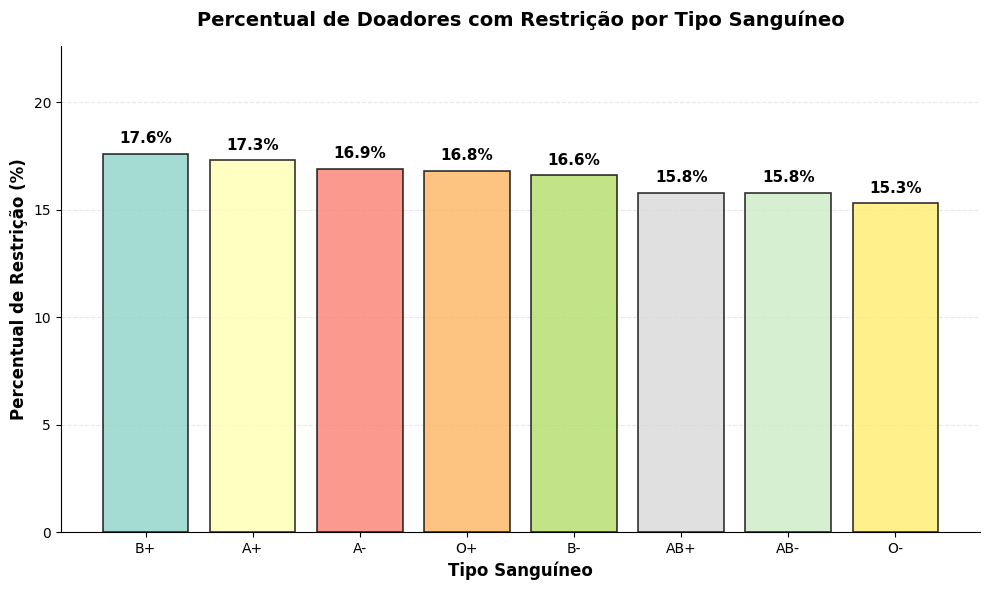

In [49]:
fig, ax3 = plt.subplots(figsize=(10, 6))
total_por_tipo = df['blood_type'].value_counts()
percentual_restricao = (contagem_restricao / total_por_tipo * 100).round(1)
percentual_restricao = percentual_restricao.sort_values(ascending=False)
bars = ax3.bar(percentual_restricao.index, percentual_restricao.values, color=cores_barras,
               edgecolor='black', linewidth=1.2, alpha=0.8)
for bar, val in zip(bars, percentual_restricao.values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
ax3.set_ylabel('Percentual de Restrição (%)', fontsize=12, fontweight='semibold')
ax3.set_title('Percentual de Doadores com Restrição por Tipo Sanguíneo',
              fontsize=14, fontweight='bold', pad=15)
ax3.set_ylim(0, max(percentual_restricao.values) + 5)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

####Histograma hipótese 2
Aqui estará as informações de histograma para a segunda hipótese:

2. Quantidade de doadores por sexo.

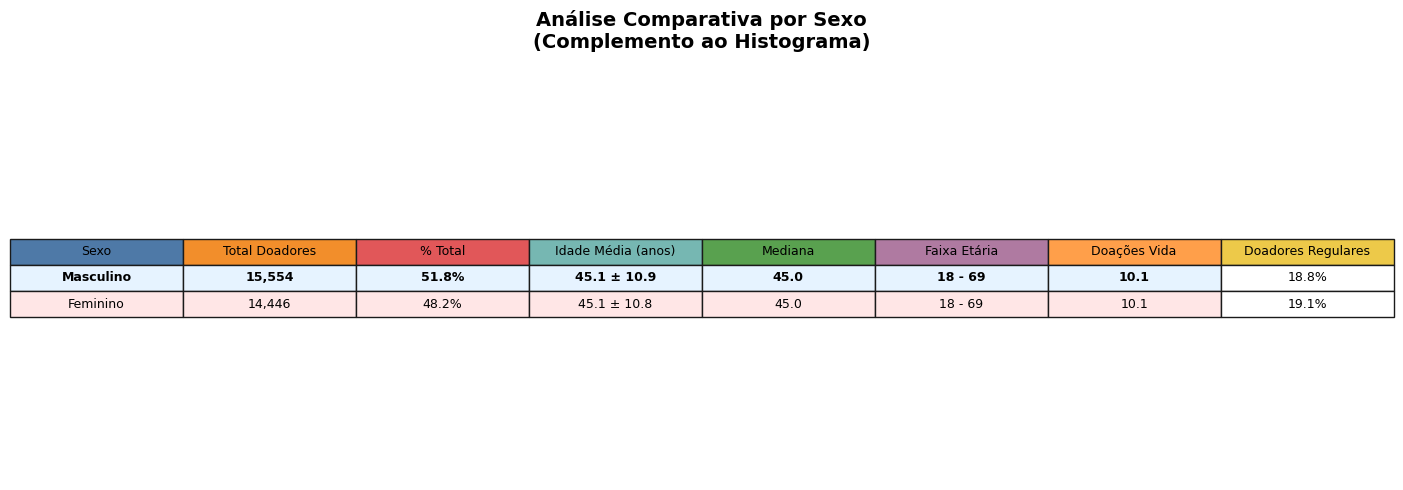

In [168]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
total = len(df)
estatisticas_hip2 = pd.DataFrame({
    'Sexo': ['Masculino', 'Feminino'],
    'Total_Doadores': [len(df_masculino), len(df_feminino)],
    'Percentual': [len(df_masculino)/total*100, len(df_feminino)/total*100],
    'Idade_Media': [df_masculino['age'].mean(), df_feminino['age'].mean()],
    'Idade_Desvio': [df_masculino['age'].std(), df_feminino['age'].std()],
    'Idade_Mediana': [df_masculino['age'].median(), df_feminino['age'].median()],
    'Idade_Min': [df_masculino['age'].min(), df_feminino['age'].min()],
    'Idade_Max': [df_masculino['age'].max(), df_feminino['age'].max()],
    'Doacoes_Vida_Media': [df_masculino['lifetime_donation_count'].mean(), df_feminino['lifetime_donation_count'].mean()],
    'Taxa_Regular': [df_masculino['is_regular_donor'].mean()*100, df_feminino['is_regular_donor'].mean()*100]
})
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Masculino',
     f"{int(estatisticas_hip2.loc[0, 'Total_Doadores']):,}",
     f"{estatisticas_hip2.loc[0, 'Percentual']:.1f}%",
     f"{estatisticas_hip2.loc[0, 'Idade_Media']:.1f} ± {estatisticas_hip2.loc[0, 'Idade_Desvio']:.1f}",
     f"{estatisticas_hip2.loc[0, 'Idade_Mediana']:.1f}",
     f"{estatisticas_hip2.loc[0, 'Idade_Min']:.0f} - {estatisticas_hip2.loc[0, 'Idade_Max']:.0f}",
     f"{estatisticas_hip2.loc[0, 'Doacoes_Vida_Media']:.1f}",
     f"{estatisticas_hip2.loc[0, 'Taxa_Regular']:.1f}%"],
    ['Feminino',
     f"{int(estatisticas_hip2.loc[1, 'Total_Doadores']):,}",
     f"{estatisticas_hip2.loc[1, 'Percentual']:.1f}%",
     f"{estatisticas_hip2.loc[1, 'Idade_Media']:.1f} ± {estatisticas_hip2.loc[1, 'Idade_Desvio']:.1f}",
     f"{estatisticas_hip2.loc[1, 'Idade_Mediana']:.1f}",
     f"{estatisticas_hip2.loc[1, 'Idade_Min']:.0f} - {estatisticas_hip2.loc[1, 'Idade_Max']:.0f}",
     f"{estatisticas_hip2.loc[1, 'Doacoes_Vida_Media']:.1f}",
     f"{estatisticas_hip2.loc[1, 'Taxa_Regular']:.1f}%"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Sexo', 'Total Doadores', '% Total',
                             'Idade Média (anos)', 'Mediana', 'Faixa Etária',
                             'Doações Vida', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a', '#edc949', '#9c9c9c'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.5)
for j in range(7):
    cell = tabela[(1, j)]
    cell.set_facecolor('#e6f3ff')
    cell.set_text_props(weight='bold')
for j in range(7):
    cell = tabela[(2, j)]
    cell.set_facecolor('#ffe6e6')
plt.title('Análise Comparativa por Sexo\n(Complemento ao Histograma)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

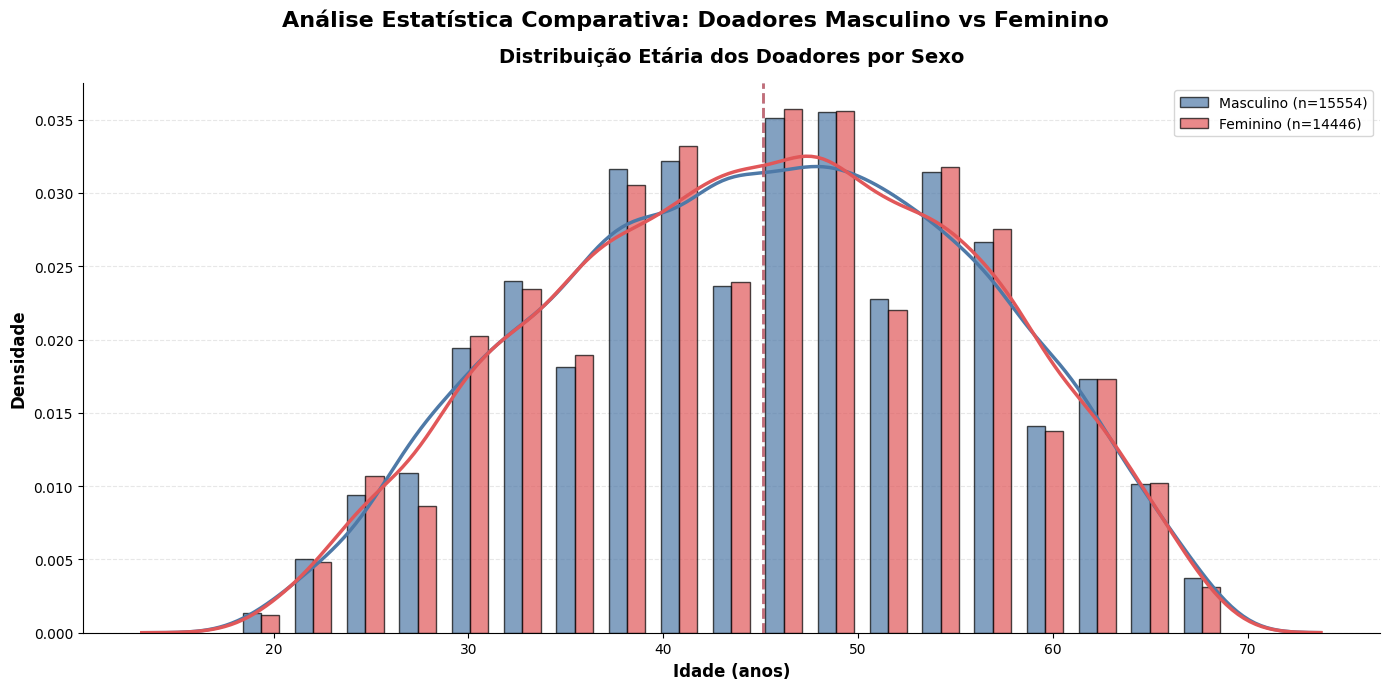

In [48]:
plt.style.use('default')
sns.set_palette("husl")
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
bins = np.linspace(df['age'].min(), df['age'].max(), 20)
hist_masc, bin_edges = np.histogram(df_masculino['age'], bins=bins, density=True)
hist_fem, _ = np.histogram(df_feminino['age'], bins=bins, density=True)
x = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0]) * 0.35
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Análise Estatística Comparativa: Doadores Masculino vs Feminino',
             fontsize=16, fontweight='bold', y=0.98)
bars1 = ax1.bar(x - width/2, hist_masc, width, alpha=0.7, color='#4e79a7',
                edgecolor='black', linewidth=1, label=f'Masculino (n={len(df_masculino)})')
bars2 = ax1.bar(x + width/2, hist_fem, width, alpha=0.7, color='#e15759',
                edgecolor='black', linewidth=1, label=f'Feminino (n={len(df_feminino)})')
sns.kdeplot(df_masculino['age'], color='#4e79a7', linewidth=2.5, ax=ax1, linestyle='-')
sns.kdeplot(df_feminino['age'], color='#e15759', linewidth=2.5, ax=ax1, linestyle='-')
ax1.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax1.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax1.set_title('Distribuição Etária dos Doadores por Sexo', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
media_m = df_masculino['age'].mean()
media_f = df_feminino['age'].mean()
ax1.axvline(x=media_m, color='#4e79a7', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média Masculino: {media_m:.1f} anos')
ax1.axvline(x=media_f, color='#e15759', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média Feminino: {media_f:.1f} anos')
plt.tight_layout()
plt.show()

####Histograma hipótese 3
Aqui estará as informações de histograma para a terceira hipótese:

3. Doadores de sangue fumantes.

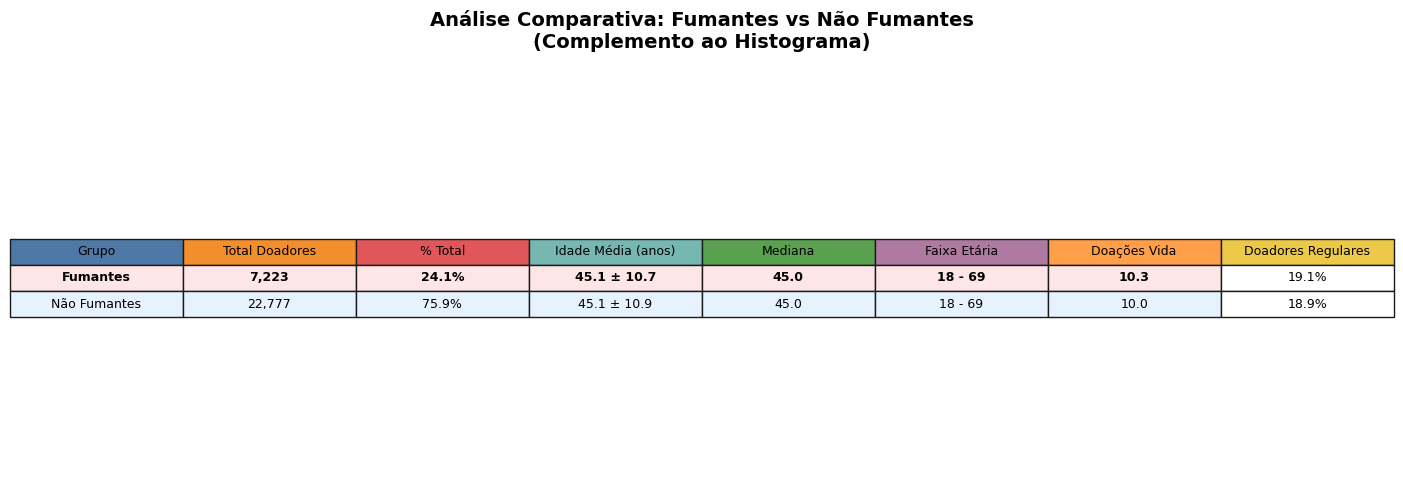

In [171]:
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
total = len(df)
estatisticas_hip3 = pd.DataFrame({
    'Grupo': ['Fumantes', 'Não Fumantes'],
    'Total_Doadores': [len(df_fumantes), len(df_nao_fumantes)],
    'Percentual': [len(df_fumantes)/total*100, len(df_nao_fumantes)/total*100],
    'Idade_Media': [df_fumantes['age'].mean(), df_nao_fumantes['age'].mean()],
    'Idade_Desvio': [df_fumantes['age'].std(), df_nao_fumantes['age'].std()],
    'Idade_Mediana': [df_fumantes['age'].median(), df_nao_fumantes['age'].median()],
    'Idade_Min': [df_fumantes['age'].min(), df_nao_fumantes['age'].min()],
    'Idade_Max': [df_fumantes['age'].max(), df_nao_fumantes['age'].max()],
    'Doacoes_Vida_Media': [df_fumantes['lifetime_donation_count'].mean(), df_nao_fumantes['lifetime_donation_count'].mean()],
    'Taxa_Regular': [df_fumantes['is_regular_donor'].mean()*100, df_nao_fumantes['is_regular_donor'].mean()*100]
})
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Fumantes',
     f"{int(estatisticas_hip3.loc[0, 'Total_Doadores']):,}",
     f"{estatisticas_hip3.loc[0, 'Percentual']:.1f}%",
     f"{estatisticas_hip3.loc[0, 'Idade_Media']:.1f} ± {estatisticas_hip3.loc[0, 'Idade_Desvio']:.1f}",
     f"{estatisticas_hip3.loc[0, 'Idade_Mediana']:.1f}",
     f"{estatisticas_hip3.loc[0, 'Idade_Min']:.0f} - {estatisticas_hip3.loc[0, 'Idade_Max']:.0f}",
     f"{estatisticas_hip3.loc[0, 'Doacoes_Vida_Media']:.1f}",
     f"{estatisticas_hip3.loc[0, 'Taxa_Regular']:.1f}%"],
    ['Não Fumantes',
     f"{int(estatisticas_hip3.loc[1, 'Total_Doadores']):,}",
     f"{estatisticas_hip3.loc[1, 'Percentual']:.1f}%",
     f"{estatisticas_hip3.loc[1, 'Idade_Media']:.1f} ± {estatisticas_hip3.loc[1, 'Idade_Desvio']:.1f}",
     f"{estatisticas_hip3.loc[1, 'Idade_Mediana']:.1f}",
     f"{estatisticas_hip3.loc[1, 'Idade_Min']:.0f} - {estatisticas_hip3.loc[1, 'Idade_Max']:.0f}",
     f"{estatisticas_hip3.loc[1, 'Doacoes_Vida_Media']:.1f}",
     f"{estatisticas_hip3.loc[1, 'Taxa_Regular']:.1f}%"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Grupo', 'Total Doadores', '% Total',
                             'Idade Média (anos)', 'Mediana', 'Faixa Etária',
                             'Doações Vida', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a', '#edc949'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.5)
for j in range(7):
    cell = tabela[(1, j)]
    cell.set_facecolor('#ffe6e6')
    cell.set_text_props(weight='bold')
for j in range(7):
    cell = tabela[(2, j)]
    cell.set_facecolor('#e6f3ff')
plt.title('Análise Comparativa: Fumantes vs Não Fumantes\n(Complemento ao Histograma)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

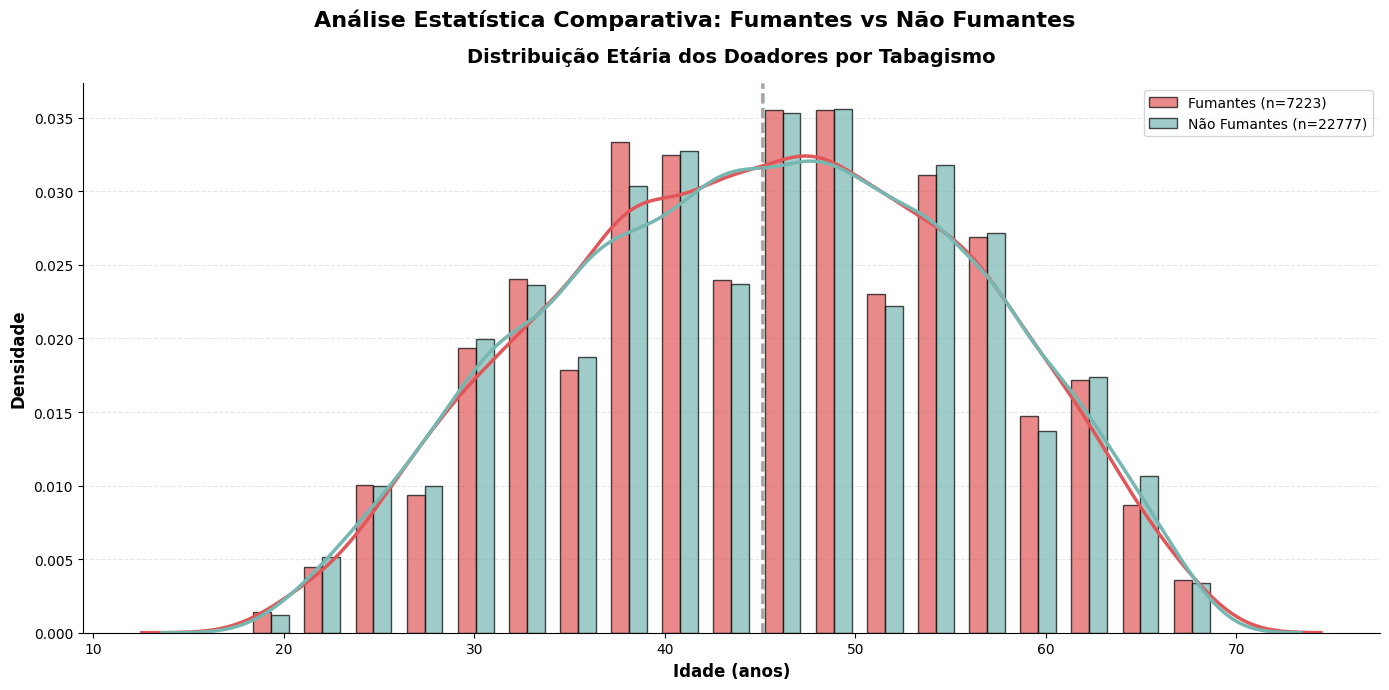

In [47]:
plt.style.use('default')
sns.set_palette("husl")
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
bins = np.linspace(df['age'].min(), df['age'].max(), 20)
hist_fum, bin_edges = np.histogram(df_fumantes['age'], bins=bins, density=True)
hist_naofum, _ = np.histogram(df_nao_fumantes['age'], bins=bins, density=True)
x = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0]) * 0.35
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Análise Estatística Comparativa: Fumantes vs Não Fumantes',
             fontsize=16, fontweight='bold', y=0.98)
bars1 = ax1.bar(x - width/2, hist_fum, width, alpha=0.7, color='#e15759',
                edgecolor='black', linewidth=1, label=f'Fumantes (n={len(df_fumantes)})')
bars2 = ax1.bar(x + width/2, hist_naofum, width, alpha=0.7, color='#76b7b2',
                edgecolor='black', linewidth=1, label=f'Não Fumantes (n={len(df_nao_fumantes)})')
sns.kdeplot(df_fumantes['age'], color='#e15759', linewidth=2.5, ax=ax1, linestyle='-')
sns.kdeplot(df_nao_fumantes['age'], color='#76b7b2', linewidth=2.5, ax=ax1, linestyle='-')
ax1.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax1.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax1.set_title('Distribuição Etária dos Doadores por Tabagismo', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
media_f = df_fumantes['age'].mean()
media_nf = df_nao_fumantes['age'].mean()
ax1.axvline(x=media_f, color='#e15759', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média Fumantes: {media_f:.1f} anos')
ax1.axvline(x=media_nf, color='#76b7b2', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média Não Fumantes: {media_nf:.1f} anos')
plt.tight_layout()
plt.show()

### Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


#### Boxplot hipótese 1
Aqui estará as informações de Boxplot para a primeira hipótese:

1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

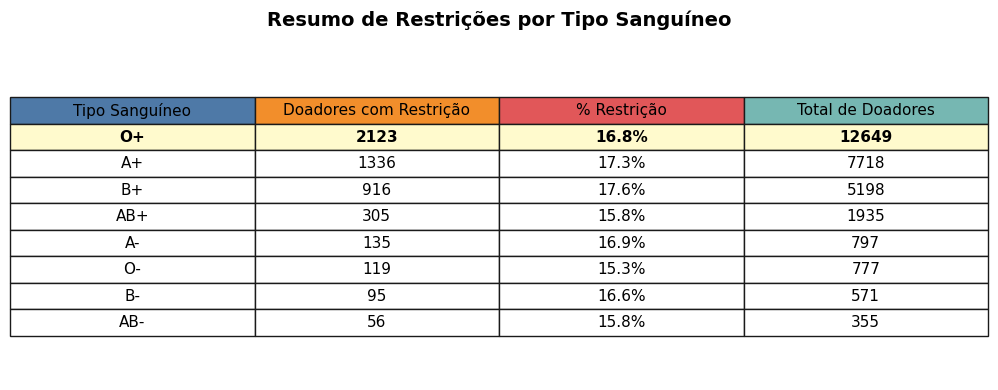

In [124]:
fig, ax = plt.subplots(figsize=(10, max(4, len(contagem_restricao) * 0.5)))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in contagem_restricao.index:
    tabela_data.append([
        tipo,
        int(contagem_restricao[tipo]),
        f"{percentual_restricao[tipo]:.1f}%",
        int(total_por_tipo[tipo])
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores com Restrição', '% Restrição', 'Total de Doadores'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.5)
for j in range(4):
    cell = tabela[(1, j)]
    cell.set_facecolor('#fffacd')
    cell.set_text_props(weight='bold')
plt.title('Resumo de Restrições por Tipo Sanguíneo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

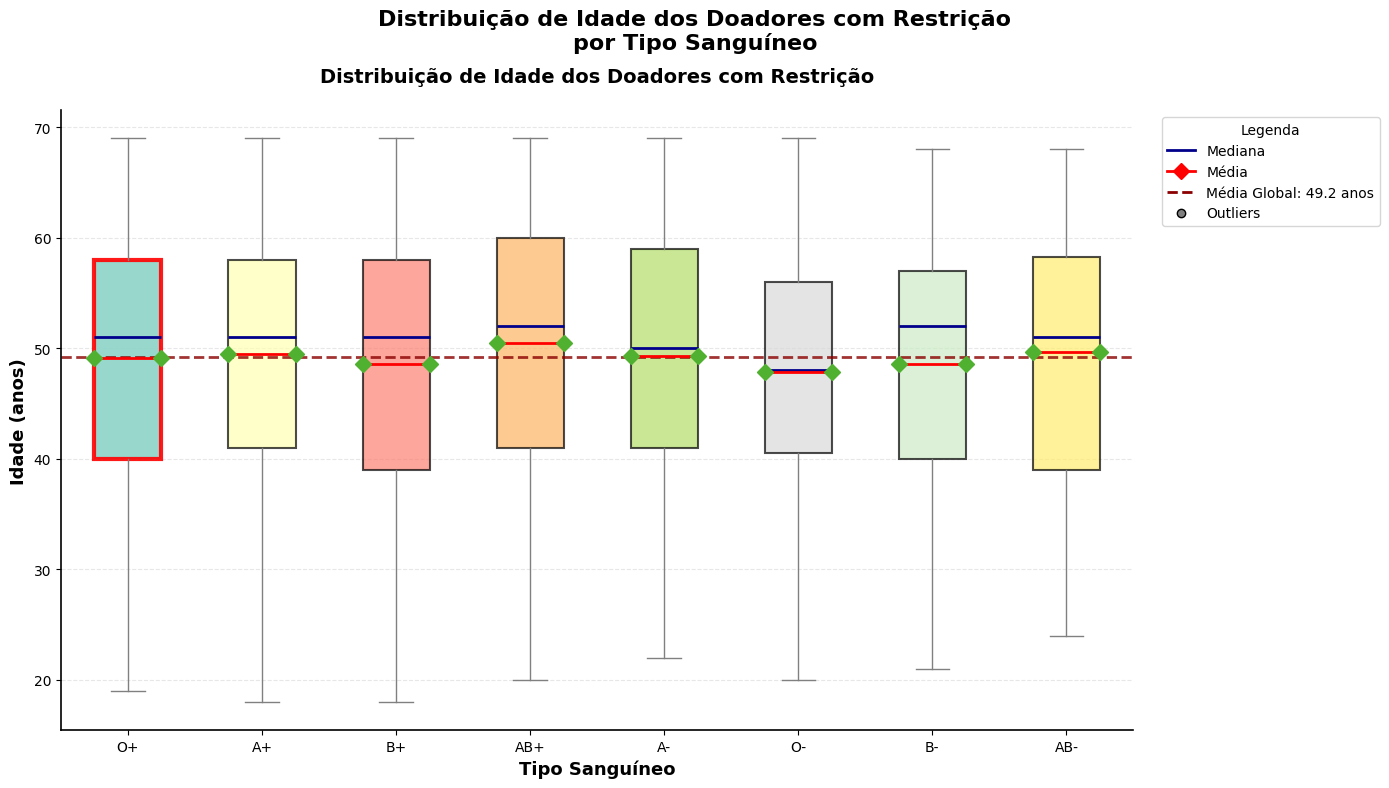

In [135]:
plt.style.use('default')
sns.set_palette("husl")
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
contagem_restricao = df_com_restricao['blood_type'].value_counts()
ordem_tipos = contagem_restricao.index.tolist()
tipo_mais_restrito = ordem_tipos[0]
dados_boxplot = []
for tipo in ordem_tipos:
    dados_tipo = df_com_restricao[df_com_restricao['blood_type'] == tipo]['age'].values
    dados_boxplot.append(dados_tipo)
cores = plt.cm.Set3(np.linspace(0, 1, len(ordem_tipos)))
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Distribuição de Idade dos Doadores com Restrição\npor Tipo Sanguíneo',
             fontsize=16, fontweight='bold', y=0.98)
bp = ax.boxplot(dados_boxplot, tick_labels=ordem_tipos, patch_artist=True,
                showmeans=True, meanline=True, meanprops=dict(color='red', linewidth=2, linestyle='-'),
                medianprops=dict(color='darkblue', linewidth=2),
                whiskerprops=dict(color='gray', linewidth=1),
                capprops=dict(color='gray', linewidth=1))
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(cores[i])
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)
    if ordem_tipos[i] == tipo_mais_restrito:
        box.set_edgecolor('red')
        box.set_linewidth(3)
        box.set_alpha(0.9)
for median in bp['medians']:
    median.set_color('darkblue')
    median.set_linewidth(2)
for mean in bp['means']:
    mean.set_color('red')
    mean.set_linewidth(2)
    mean.set_marker('D')
    mean.set_markersize(8)
for flier in bp['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('gray')
    flier.set_markeredgecolor('black')
    flier.set_markersize(5)
    flier.set_alpha(0.5)
media_global = df_com_restricao['age'].mean()
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Global: {media_global:.1f} anos')
ax.set_xlabel('Tipo Sanguíneo', fontsize=13, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=13, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores com Restrição', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
          fontsize=10, frameon=True, title='Legenda')
plt.tight_layout()
plt.show()

#### Boxplot hipótese 2
Aqui estará as informações de Boxplot para a segunda hipótese:

2. Quantidade de doadores por sexo.

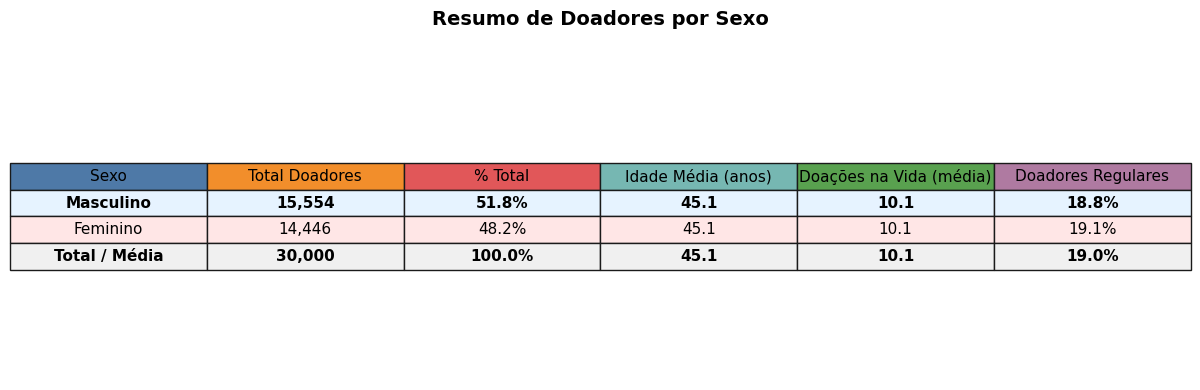

In [141]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
total = len(df)
contagem_sexo = {
    'Masculino': {
        'total': len(df_masculino),
        'percentual': len(df_masculino)/total*100
    },
    'Feminino': {
        'total': len(df_feminino),
        'percentual': len(df_feminino)/total*100
    }
}
idade_masc = df_masculino['age'].mean()
idade_fem = df_feminino['age'].mean()
idade_global = df['age'].mean()
doacoes_vida_masc = df_masculino['lifetime_donation_count'].mean()
doacoes_vida_fem = df_feminino['lifetime_donation_count'].mean()
regulares_masc = df_masculino['is_regular_donor'].mean() * 100
regulares_fem = df_feminino['is_regular_donor'].mean() * 100
tabela_data = [
    ['Masculino',
     f"{contagem_sexo['Masculino']['total']:,}",
     f"{contagem_sexo['Masculino']['percentual']:.1f}%",
     f"{idade_masc:.1f}",
     f"{doacoes_vida_masc:.1f}",
     f"{regulares_masc:.1f}%"],
    ['Feminino',
     f"{contagem_sexo['Feminino']['total']:,}",
     f"{contagem_sexo['Feminino']['percentual']:.1f}%",
     f"{idade_fem:.1f}",
     f"{doacoes_vida_fem:.1f}",
     f"{regulares_fem:.1f}%"],
    ['Total / Média',
     f"{total:,}",
     f"100.0%",
     f"{idade_global:.1f}",
     f"{(doacoes_vida_masc + doacoes_vida_fem)/2:.1f}",
     f"{(regulares_masc + regulares_fem)/2:.1f}%"]
]
fig, ax = plt.subplots(figsize=(12, max(4, len(tabela_data) * 0.5)))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Sexo', 'Total Doadores', '% Total', 'Idade Média (anos)',
                             'Doações na Vida (média)', 'Doadores Regulares'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.5)
for j in range(6):
    cell = tabela[(1, j)]
    cell.set_facecolor('#e6f3ff')
    cell.set_text_props(weight='bold')
for j in range(6):
    cell = tabela[(2, j)]
    cell.set_facecolor('#ffe6e6')
for j in range(6):
    cell = tabela[(3, j)]
    cell.set_facecolor('#f0f0f0')
    cell.set_text_props(weight='bold')
plt.title('Resumo de Doadores por Sexo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

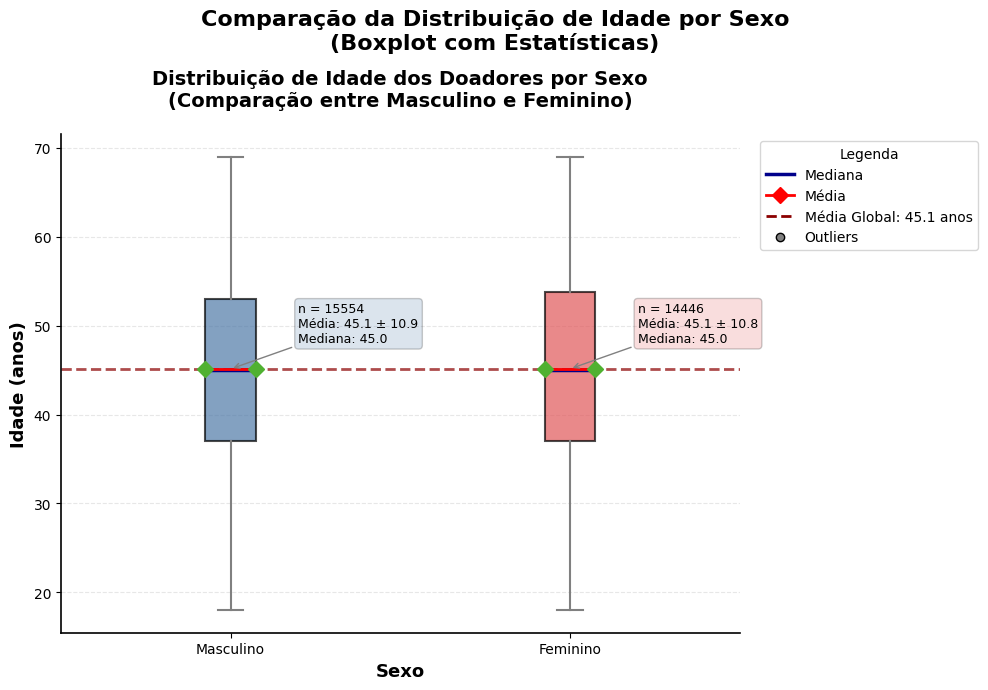

In [139]:
plt.style.use('default')
sns.set_palette("husl")
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
total_masc = len(df_masculino)
total_fem = len(df_feminino)
media_masc = df_masculino['age'].mean()
media_fem = df_feminino['age'].mean()
mediana_masc = df_masculino['age'].median()
mediana_fem = df_feminino['age'].median()
std_masc = df_masculino['age'].std()
std_fem = df_feminino['age'].std()
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Comparação da Distribuição de Idade por Sexo\n(Boxplot com Estatísticas)',
             fontsize=16, fontweight='bold', y=0.98)
dados_boxplot = [df_masculino['age'].values, df_feminino['age'].values]
nomes_sexos = ['Masculino', 'Feminino']
cores = ['#4e79a7', '#e15759']
bp = ax.boxplot(dados_boxplot, tick_labels=nomes_sexos, patch_artist=True,
                showmeans=True, meanline=True, meanprops=dict(color='red', linewidth=2, linestyle='-'),
                medianprops=dict(color='darkblue', linewidth=2),
                whiskerprops=dict(color='gray', linewidth=1.5),
                capprops=dict(color='gray', linewidth=1.5))
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(cores[i])
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)
for median in bp['medians']:
    median.set_color('darkblue')
    median.set_linewidth(2.5)
for mean in bp['means']:
    mean.set_color('red')
    mean.set_linewidth(2)
    mean.set_marker('D')
    mean.set_markersize(8)
for flier in bp['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('gray')
    flier.set_markeredgecolor('black')
    flier.set_markersize(5)
    flier.set_alpha(0.5)
media_global = df['age'].mean()
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Média Global: {media_global:.1f} anos')
ax.annotate(f'n = {total_masc}\nMédia: {media_masc:.1f} ± {std_masc:.1f}\nMediana: {mediana_masc:.1f}',
            xy=(1, media_masc), xytext=(1.2, media_masc + 3),
            ha='left', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='#4e79a7', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.annotate(f'n = {total_fem}\nMédia: {media_fem:.1f} ± {std_fem:.1f}\nMediana: {mediana_fem:.1f}',
            xy=(2, media_fem), xytext=(2.2, media_fem + 3),
            ha='left', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='#e15759', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_xlabel('Sexo', fontsize=13, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=13, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores por Sexo\n(Comparação entre Masculino e Feminino)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2.5, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
          fontsize=10, frameon=True, title='Legenda')
plt.tight_layout()
plt.show()

#### Boxplot hipótese 3
Aqui estará as informações de Boxplot para a terceira hipótese:

3. Doadores de sangue fumantes.

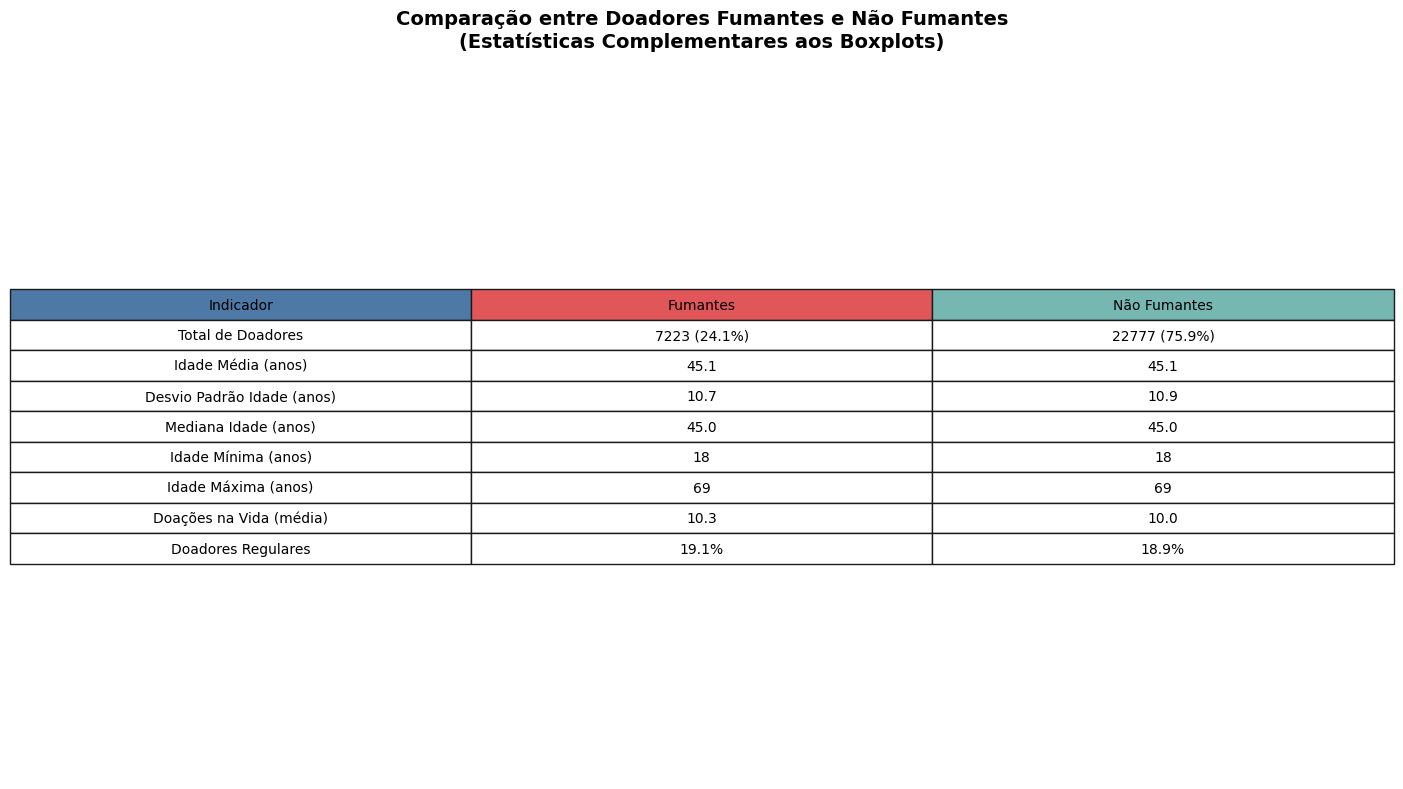

In [143]:
fumantes = df[df['smoker'] == 1]
nao_fumantes = df[df['smoker'] == 0]
dados_fumantes = {
    'Indicador': [
        'Total de Doadores',
        'Idade Média (anos)',
        'Desvio Padrão Idade (anos)',
        'Mediana Idade (anos)',
        'Idade Mínima (anos)',
        'Idade Máxima (anos)',
        'Doações na Vida (média)',
        'Doadores Regulares'
    ],
    'Fumantes': [
        f"{len(fumantes)} ({len(fumantes)/len(df)*100:.1f}%)",
        f"{fumantes['age'].mean():.1f}",
        f"{fumantes['age'].std():.1f}",
        f"{fumantes['age'].median():.1f}",
        f"{fumantes['age'].min():.0f}",
        f"{fumantes['age'].max():.0f}",
        f"{fumantes['lifetime_donation_count'].mean():.1f}",
        f"{fumantes['is_regular_donor'].mean()*100:.1f}%"
    ],
    'Não Fumantes': [
        f"{len(nao_fumantes)} ({len(nao_fumantes)/len(df)*100:.1f}%)",
        f"{nao_fumantes['age'].mean():.1f}",
        f"{nao_fumantes['age'].std():.1f}",
        f"{nao_fumantes['age'].median():.1f}",
        f"{nao_fumantes['age'].min():.0f}",
        f"{nao_fumantes['age'].max():.0f}",
        f"{nao_fumantes['lifetime_donation_count'].mean():.1f}",
        f"{nao_fumantes['is_regular_donor'].mean()*100:.1f}%"
    ]
}
df_fumantes = pd.DataFrame(dados_fumantes)
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=df_fumantes.values,
                  colLabels=df_fumantes.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Comparação entre Doadores Fumantes e Não Fumantes\n(Estatísticas Complementares aos Boxplots)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

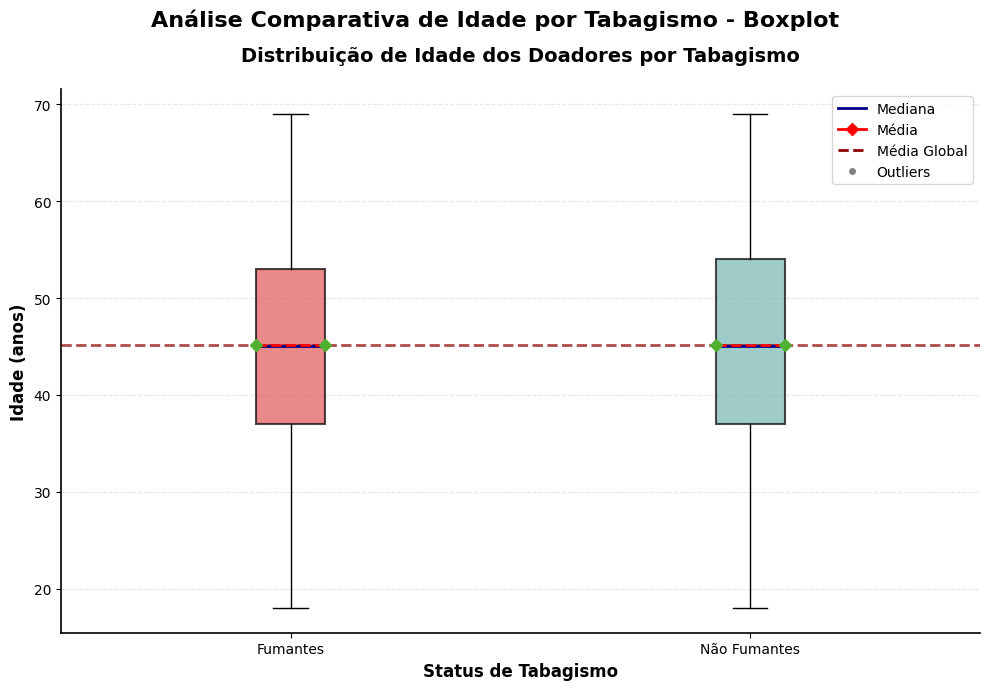

In [38]:
plt.style.use('default')
sns.set_palette("husl")
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
ordem_status = [1, 0]
nomes_status = {1: 'Fumantes', 0: 'Não Fumantes'}
dados_boxplot = [
    df_fumantes['age'].values,
    df_nao_fumantes['age'].values
]
cores = ['#e15759', '#76b7b2']
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Análise Comparativa de Idade por Tabagismo - Boxplot',
             fontsize=16, fontweight='bold', y=0.98)
bp = ax.boxplot(dados_boxplot, tick_labels=[nomes_status[status] for status in ordem_status],
                patch_artist=True, showmeans=True, meanline=True,
                meanprops=dict(color='red', linewidth=2))

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(cores[i])
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

for median in bp['medians']:
    median.set_color('darkblue')
    median.set_linewidth(2)

for mean in bp['means']:
    mean.set_color('red')
    mean.set_linewidth(2)
    mean.set_marker('D')
    mean.set_markersize(6)

for flier in bp['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('gray')
    flier.set_markeredgecolor('black')
    flier.set_markersize(4)
    flier.set_alpha(0.5)

media_global = df['age'].mean()
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Média Global: {media_global:.1f} anos')
ax.set_xlabel('Status de Tabagismo', fontsize=12, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores por Tabagismo',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red', label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label='Média Global'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

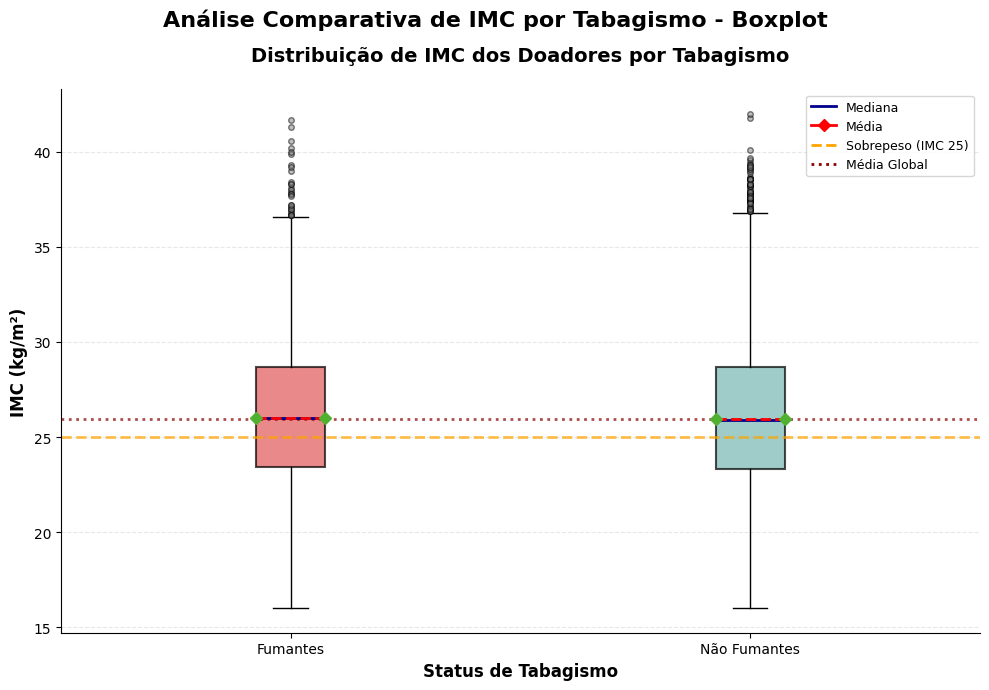

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Análise Comparativa de IMC por Tabagismo - Boxplot',
             fontsize=16, fontweight='bold', y=0.98)
dados_imc = [
    df_fumantes['bmi'].values,
    df_nao_fumantes['bmi'].values
]
bp2 = ax.boxplot(dados_imc, tick_labels=[nomes_status[status] for status in ordem_status],
                 patch_artist=True, showmeans=True, meanline=True,
                 meanprops=dict(color='red', linewidth=2))

for i, box in enumerate(bp2['boxes']):
    box.set_facecolor(cores[i])
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

for median in bp2['medians']:
    median.set_color('darkblue')
    median.set_linewidth(2)

for mean in bp2['means']:
    mean.set_color('red')
    mean.set_linewidth(2)
    mean.set_marker('D')
    mean.set_markersize(6)

for flier in bp2['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('gray')
    flier.set_markeredgecolor('black')
    flier.set_markersize(4)
    flier.set_alpha(0.5)

ax.axhline(y=25, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Sobrepeso (IMC 25)')
media_global_imc = df['bmi'].mean()
ax.axhline(y=media_global_imc, color='darkred', linestyle=':', linewidth=2, alpha=0.7,
           label=f'Média Global IMC: {media_global_imc:.1f}')
ax.set_xlabel('Status de Tabagismo', fontsize=12, fontweight='semibold')
ax.set_ylabel('IMC (kg/m²)', fontsize=12, fontweight='semibold')
ax.set_title('Distribuição de IMC dos Doadores por Tabagismo',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_elements_imc = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red', label='Média'),
    Line2D([0], [0], color='orange', linestyle='--', linewidth=2, label='Sobrepeso (IMC 25)'),
    Line2D([0], [0], color='darkred', linestyle=':', linewidth=2, label='Média Global')
]
ax.legend(handles=legend_elements_imc, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

####Matriz de correleção hipótese 1
Aqui estará as informações de Matriz de correleção para a primeira hipótese:

1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

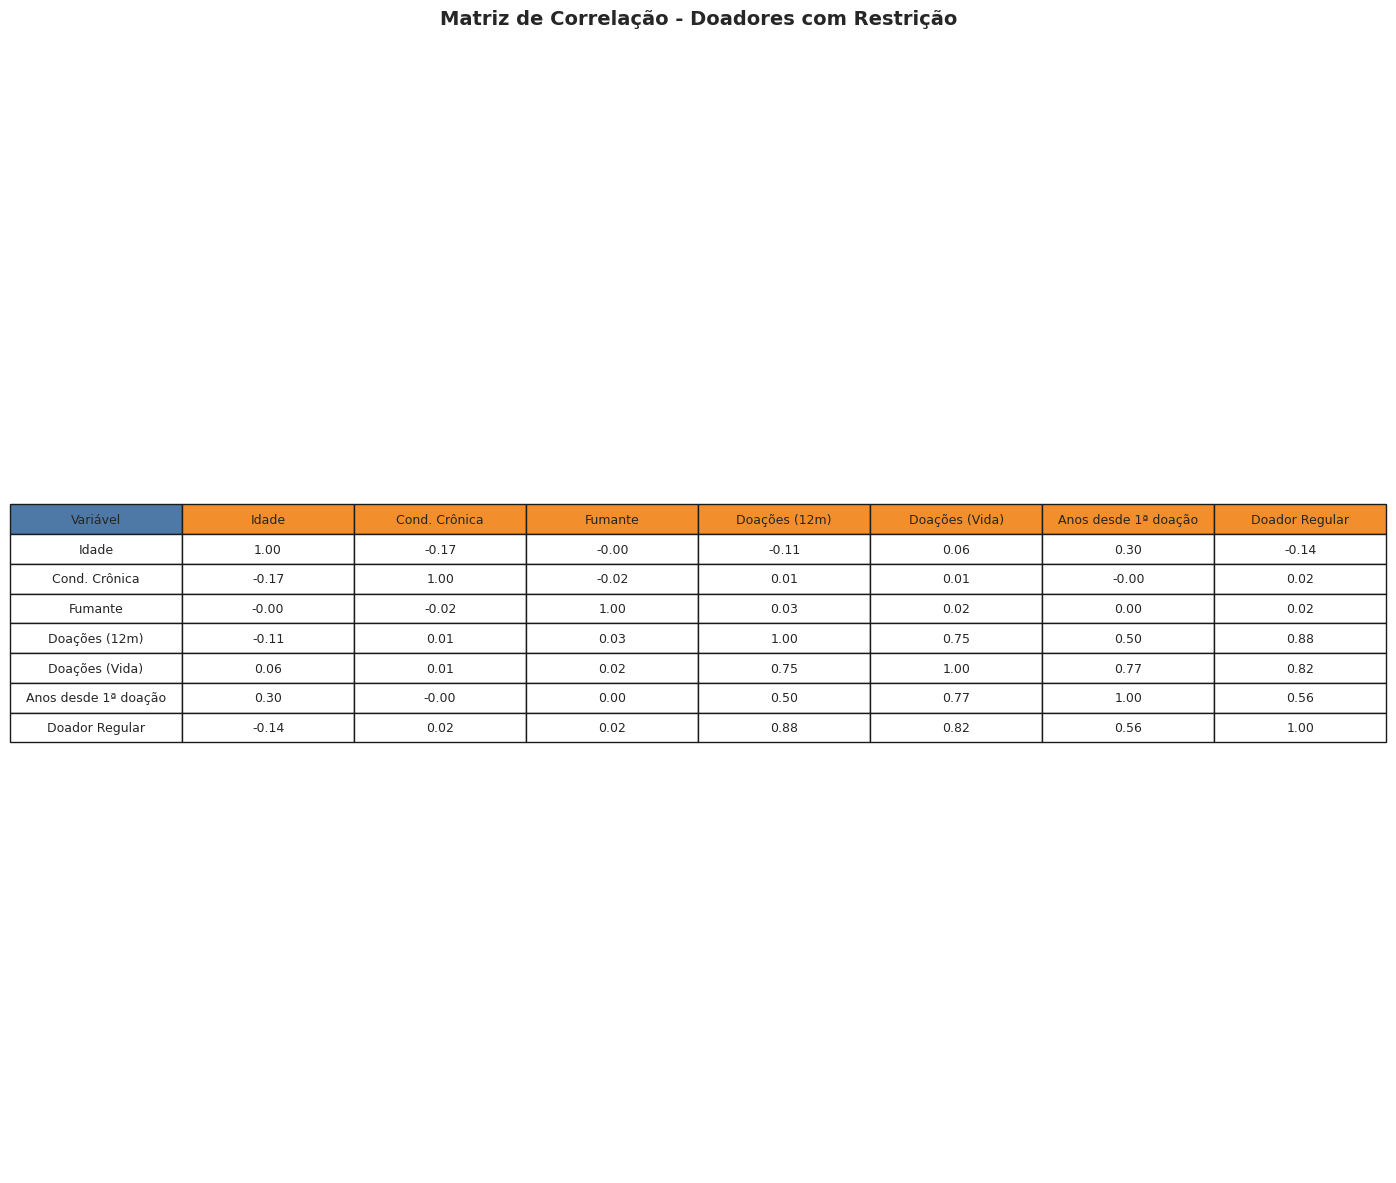

In [175]:
plt.style.use('default')
sns.set_theme(style="whitegrid")
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
variaveis_hip1 = ['age', 'chronic_condition_flag', 'smoker',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'years_since_first_donation', 'is_regular_donor']
variaveis_hip1 = [v for v in variaveis_hip1 if v in df_com_restricao.columns]
corr_hip1 = df_com_restricao[variaveis_hip1].corr()
nomes_portugues_hip1 = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'smoker': 'Fumante',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação',
    'is_regular_donor': 'Doador Regular'
}
corr_hip1_renomeada = corr_hip1.rename(index=nomes_portugues_hip1, columns=nomes_portugues_hip1)
corr_hip1_abs = corr_hip1.abs().unstack().sort_values(ascending=False).drop_duplicates()
corr_hip1_abs = corr_hip1_abs[corr_hip1_abs != 1.0]
corr_hip1_abs = corr_hip1_abs[corr_hip1_abs >= 0.3]
if len(corr_hip1_abs) > 0:
    for (var1, var2), valor in corr_hip1_abs.items():
        var1_pt = nomes_portugues_hip1.get(var1, var1)
        var2_pt = nomes_portugues_hip1.get(var2, var2)
for var in variaveis_hip1:
    var_pt = nomes_portugues_hip1.get(var, var)
    correlacoes = corr_hip1[var].drop(var).abs().sort_values(ascending=False)
    top_correlacoes = correlacoes.head(3)
    for outra, valor in top_correlacoes.items():
        outra_pt = nomes_portugues_hip1.get(outra, outra)
        sinal = "positiva" if corr_hip1.loc[var, outra] > 0 else "negativa"
fig, ax = plt.subplots(figsize=(14, 12))
ax.axis('off')
ax.axis('tight')
tabela_corr_data = []
for var1 in corr_hip1_renomeada.index:
    linha = [var1]
    for var2 in corr_hip1_renomeada.columns:
        valor = corr_hip1_renomeada.loc[var1, var2]
        if abs(valor) > 0.7:
            linha.append(f"{valor:.2f}")
        elif abs(valor) > 0.3:
            linha.append(f"{valor:.2f}")
        else:
            linha.append(f"{valor:.2f}")
    tabela_corr_data.append(linha)
tabela = ax.table(cellText=tabela_corr_data,
                  colLabels=['Variável'] + corr_hip1_renomeada.columns.tolist(),
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7'] + ['#f28e2b'] * len(corr_hip1_renomeada.columns))
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.5)
plt.title('Matriz de Correlação - Doadores com Restrição\n',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

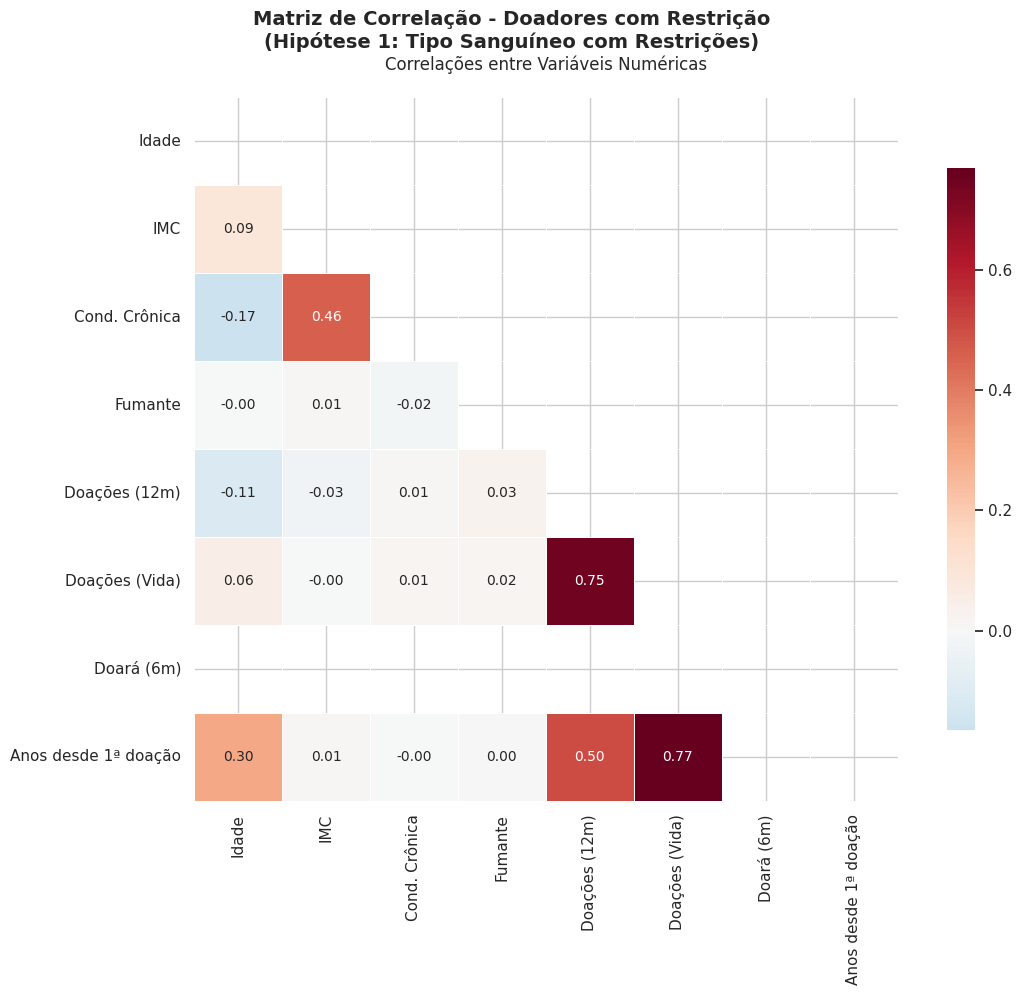

In [40]:
plt.style.use('default')
sns.set_theme(style="whitegrid")
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
variaveis_hip1 = ['age', 'bmi', 'chronic_condition_flag', 'smoker',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'donated_next_6m', 'years_since_first_donation']
variaveis_hip1 = [v for v in variaveis_hip1 if v in df_com_restricao.columns]
corr_hip1 = df_com_restricao[variaveis_hip1].corr()
nomes_portugues_hip1 = {
    'age': 'Idade',
    'bmi': 'IMC',
    'chronic_condition_flag': 'Cond. Crônica',
    'smoker': 'Fumante',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'donated_next_6m': 'Doará (6m)',
    'years_since_first_donation': 'Anos desde 1ª doação'
}
corr_hip1_renomeada = corr_hip1.rename(index=nomes_portugues_hip1, columns=nomes_portugues_hip1)
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matriz de Correlação - Doadores com Restrição\n(Hipótese 1: Tipo Sanguíneo com Restrições)',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_hip1_renomeada, dtype=bool))
sns.heatmap(corr_hip1_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 10})
ax.set_title('Correlações entre Variáveis Numéricas', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

####Matriz de correleção hipótese 2
Aqui estará as informações de Matriz de correleção para a segunda hipótese:

2. Quantidade de doadores por sexo.

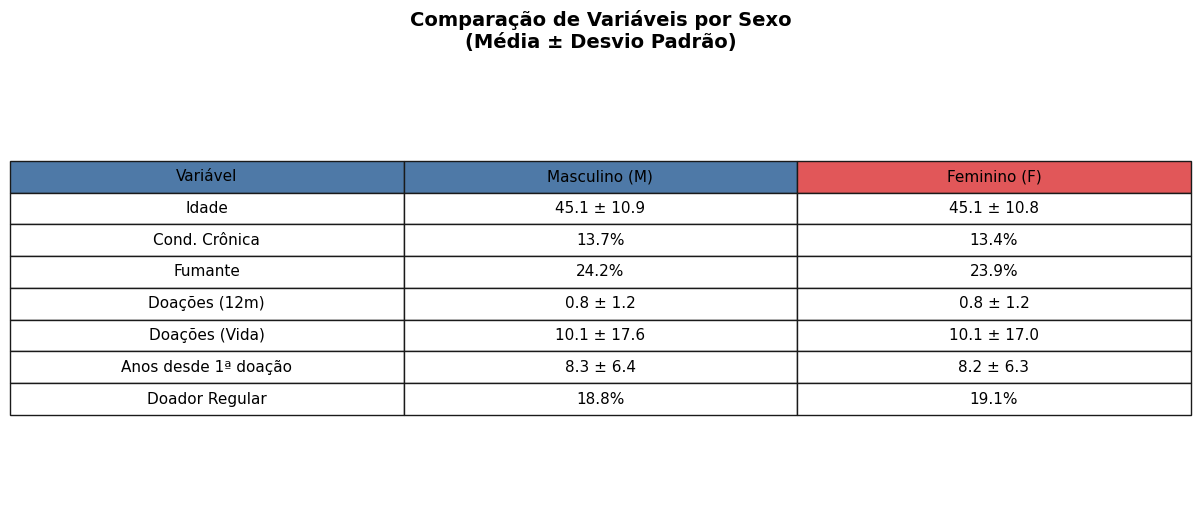

In [180]:
plt.style.use('default')
df_masculino = df[df['sex'] == 'M'].copy()
df_feminino = df[df['sex'] == 'F'].copy()
variaveis_hip2 = ['age', 'chronic_condition_flag', 'smoker',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'years_since_first_donation', 'is_regular_donor']
variaveis_hip2 = [v for v in variaveis_hip2 if v in df.columns]
nomes_portugues_hip2 = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'smoker': 'Fumante',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação',
    'is_regular_donor': 'Doador Regular'
}
tabela_data = []
for var in variaveis_hip2:
    var_pt = nomes_portugues_hip2.get(var, var)
    masc_mean = df_masculino[var].mean()
    masc_std = df_masculino[var].std()
    fem_mean = df_feminino[var].mean()
    fem_std = df_feminino[var].std()
    if var == 'chronic_condition_flag' or var == 'smoker' or var == 'is_regular_donor':
        masc_val = f"{masc_mean*100:.1f}%"
        fem_val = f"{fem_mean*100:.1f}%"
    else:
        masc_val = f"{masc_mean:.1f} ± {masc_std:.1f}"
        fem_val = f"{fem_mean:.1f} ± {fem_std:.1f}"
    tabela_data.append([var_pt, masc_val, fem_val])
fig, ax = plt.subplots(figsize=(12, len(variaveis_hip2) * 0.6 + 1))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Variável', 'Masculino (M)', 'Feminino (F)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#4e79a7', '#e15759'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.8)
plt.title('Comparação de Variáveis por Sexo\n(Média ± Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

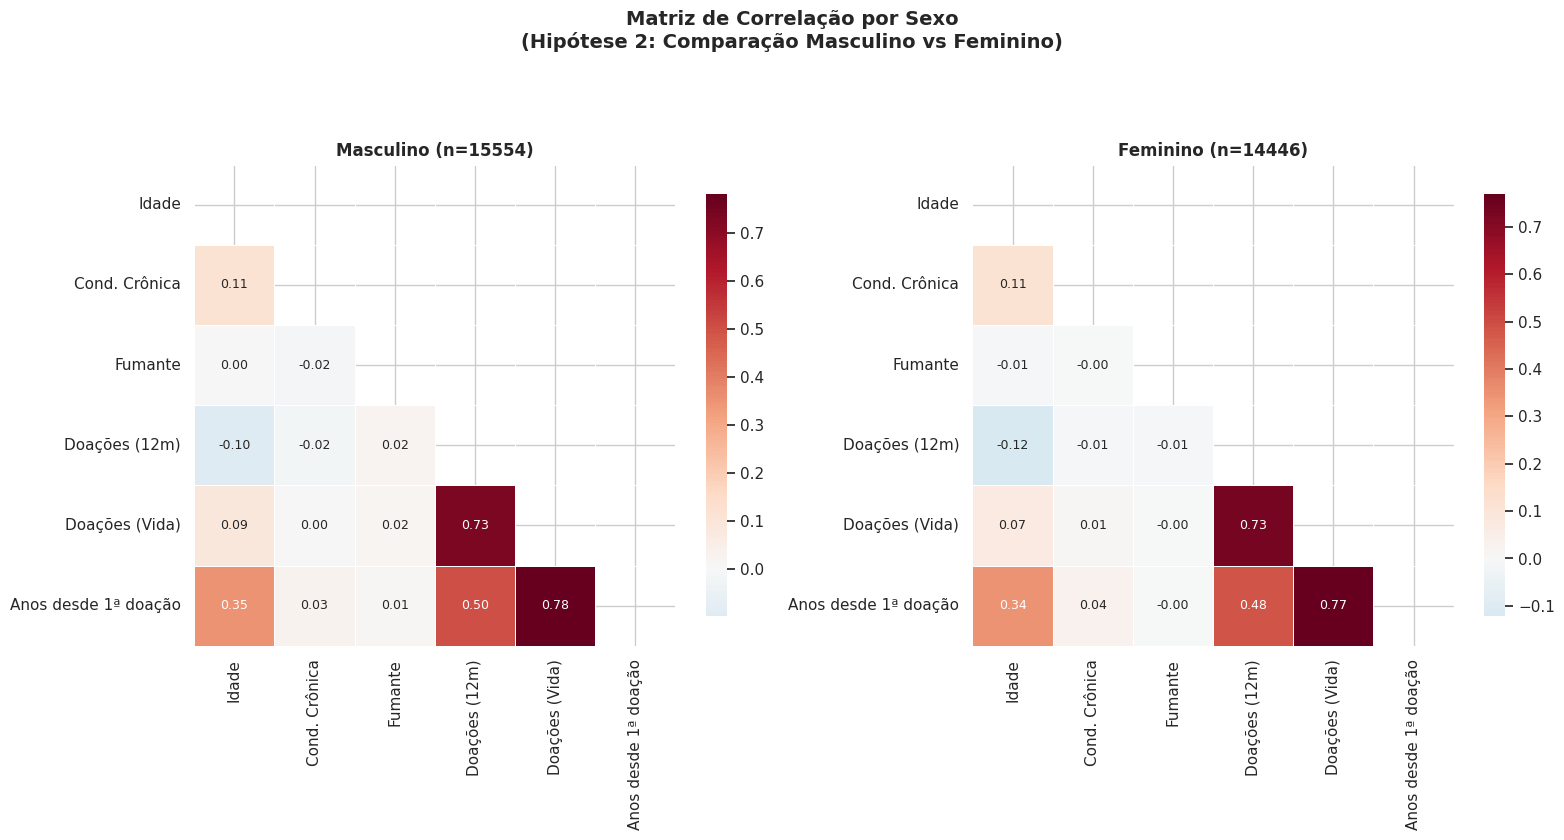

In [176]:
df_masculino = df[df['sex'] == 'M']
df_feminino = df[df['sex'] == 'F']
variaveis_hip2 = ['age', 'chronic_condition_flag', 'smoker',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'years_since_first_donation']
variaveis_hip2 = [v for v in variaveis_hip2 if v in df.columns]
nomes_portugues_hip2 = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'smoker': 'Fumante',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação'
}
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Matriz de Correlação por Sexo\n(Hipótese 2: Comparação Masculino vs Feminino)',
             fontsize=14, fontweight='bold', y=1.02)
corr_masc = df_masculino[variaveis_hip2].corr()
corr_fem = df_feminino[variaveis_hip2].corr()
corr_masc_renomeada = corr_masc.rename(index=nomes_portugues_hip2, columns=nomes_portugues_hip2)
corr_fem_renomeada = corr_fem.rename(index=nomes_portugues_hip2, columns=nomes_portugues_hip2)
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_masc_renomeada, dtype=bool))
sns.heatmap(corr_masc_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            ax=ax1, annot_kws={'size': 9})
ax1.set_title('Masculino (n={})'.format(len(df_masculino)), fontsize=12, fontweight='bold')
ax2 = axes[1]
sns.heatmap(corr_fem_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            ax=ax2, annot_kws={'size': 9})
ax2.set_title('Feminino (n={})'.format(len(df_feminino)), fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

####Matriz de correleção hipótese 3
Aqui estará as informações de Matriz de correleção para a terceira hipótese:

3. Doadores de sangue fumantes.

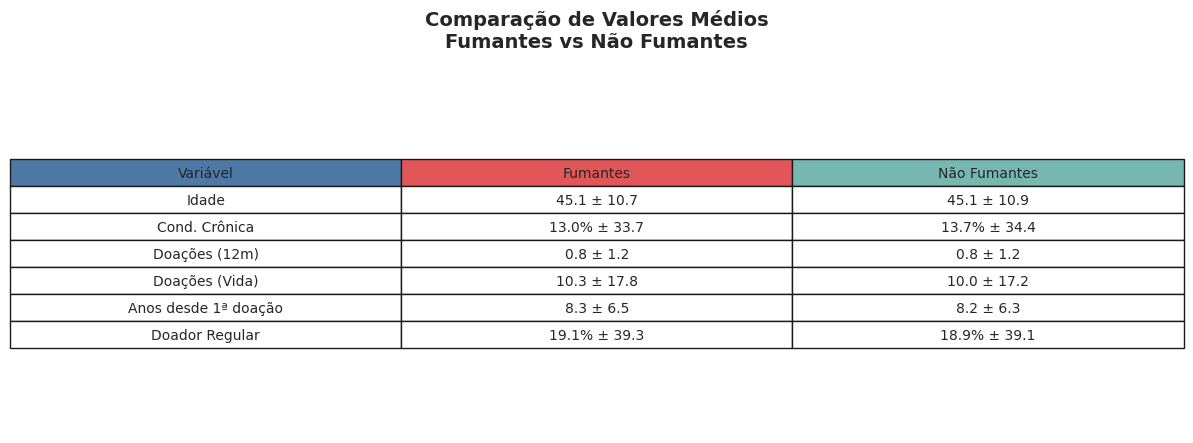

In [182]:
plt.style.use('default')
sns.set_theme(style="whitegrid")
df_fumantes = df[df['smoker'] == 1].copy()
df_nao_fumantes = df[df['smoker'] == 0].copy()
variaveis_hip3 = ['age', 'chronic_condition_flag',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'years_since_first_donation', 'is_regular_donor']
variaveis_hip3 = [v for v in variaveis_hip3 if v in df.columns]
corr_fum = df_fumantes[variaveis_hip3].corr()
corr_naofum = df_nao_fumantes[variaveis_hip3].corr()
nomes_portugues_hip3 = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação',
    'is_regular_donor': 'Doador Regular'
}
corr_fum_renomeada = corr_fum.rename(index=nomes_portugues_hip3, columns=nomes_portugues_hip3)
corr_naofum_renomeada = corr_naofum.rename(index=nomes_portugues_hip3, columns=nomes_portugues_hip3)
def principais_correlacoes(corr_matrix, nome_grupo):
    corr_abs = corr_matrix.abs().unstack().sort_values(ascending=False).drop_duplicates()
    corr_abs = corr_abs[corr_abs != 1.0]
    corr_abs = corr_abs[corr_abs >= 0.3]
    if len(corr_abs) > 0:
        for (var1, var2), valor in corr_abs.items():
            var1_pt = nomes_portugues_hip3.get(var1, var1)
            var2_pt = nomes_portugues_hip3.get(var2, var2)
            sinal = "positiva" if valor > 0 else "negativa"
principais_correlacoes(corr_fum, "Fumantes")
principais_correlacoes(corr_naofum, "Não Fumantes")
diferencas = []
for var1 in variaveis_hip3:
    for var2 in variaveis_hip3:
        if var1 != var2:
            corr_f = corr_fum.loc[var1, var2]
            corr_n = corr_naofum.loc[var1, var2]
            diferenca = abs(corr_f - corr_n)
            if diferenca > 0.2:
                diferencas.append({
                    'var1': var1,
                    'var2': var2,
                    'corr_f': corr_f,
                    'corr_n': corr_n,
                    'dif': diferenca
                })
if len(diferencas) > 0:
    for item in sorted(diferencas, key=lambda x: x['dif'], reverse=True)[:10]:
        var1_pt = nomes_portugues_hip3.get(item['var1'], item['var1'])
        var2_pt = nomes_portugues_hip3.get(item['var2'], item['var2'])
tabela_valores = []
for var in variaveis_hip3:
    var_pt = nomes_portugues_hip3.get(var, var)
    fum_mean = df_fumantes[var].mean()
    fum_std = df_fumantes[var].std()
    naofum_mean = df_nao_fumantes[var].mean()
    naofum_std = df_nao_fumantes[var].std()
    if var in ['chronic_condition_flag', 'is_regular_donor', 'donated_next_6m']:
        fum_val = f"{fum_mean*100:.1f}% ± {fum_std*100:.1f}"
        naofum_val = f"{naofum_mean*100:.1f}% ± {naofum_std*100:.1f}"
    else:
        fum_val = f"{fum_mean:.1f} ± {fum_std:.1f}"
        naofum_val = f"{naofum_mean:.1f} ± {naofum_std:.1f}"
    tabela_valores.append([var_pt, fum_val, naofum_val])
fig, ax = plt.subplots(figsize=(12, len(variaveis_hip3) * 0.6 + 1))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=tabela_valores,
                  colLabels=['Variável', 'Fumantes', 'Não Fumantes'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Comparação de Valores Médios\nFumantes vs Não Fumantes',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

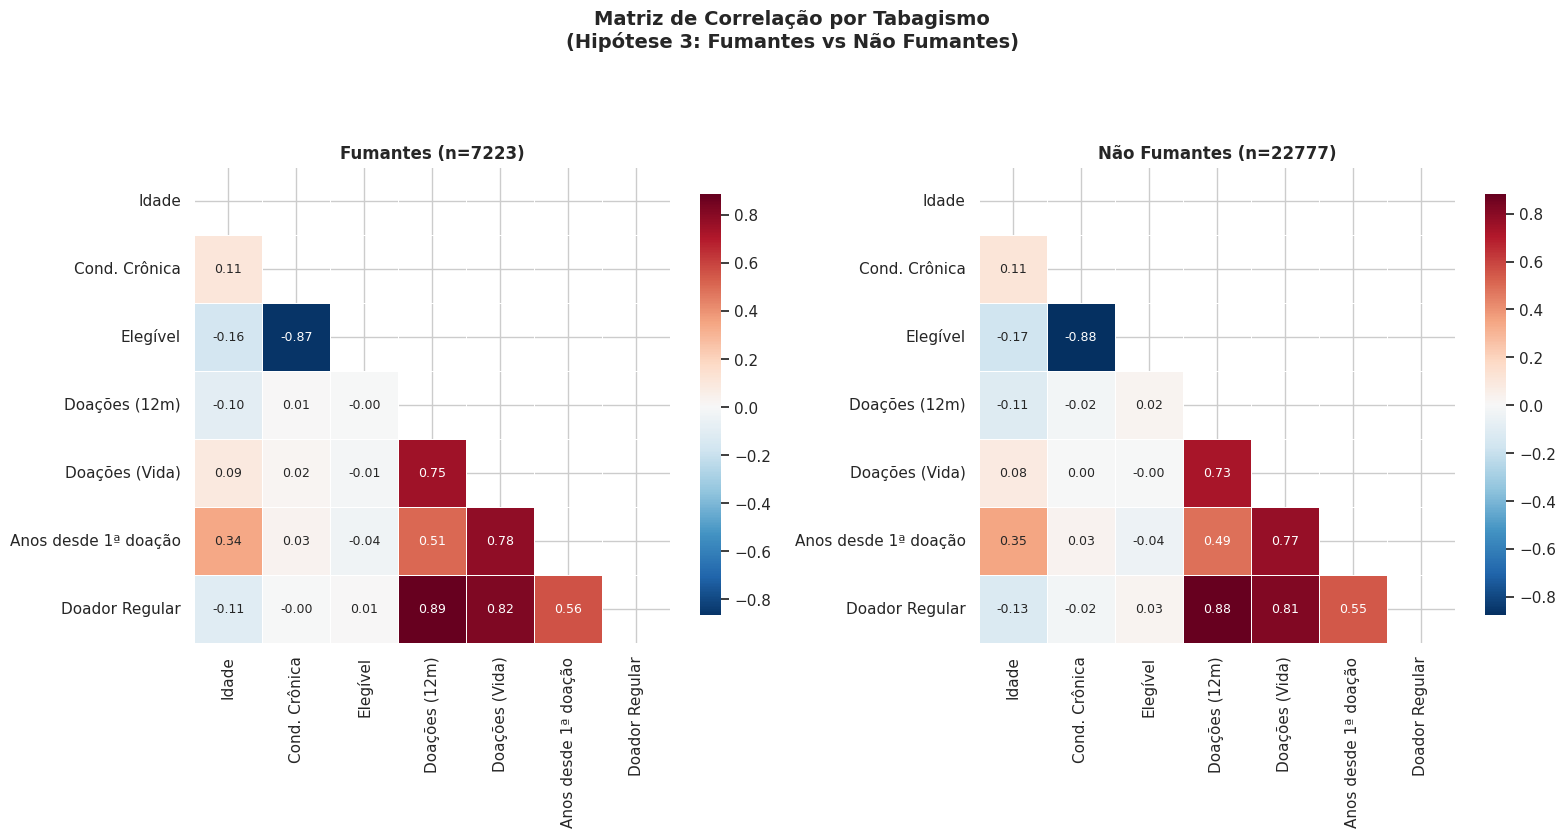

In [183]:
df_fumantes = df[df['smoker'] == 1]
df_nao_fumantes = df[df['smoker'] == 0]
variaveis_hip3 = ['age', 'chronic_condition_flag', 'eligible_to_donate',
                  'donation_count_last_12m', 'lifetime_donation_count',
                  'years_since_first_donation', 'is_regular_donor']
variaveis_hip3 = [v for v in variaveis_hip3 if v in df.columns]
nomes_portugues_hip3 = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'eligible_to_donate': 'Elegível',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação',
    'is_regular_donor': 'Doador Regular'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Matriz de Correlação por Tabagismo\n(Hipótese 3: Fumantes vs Não Fumantes)',
             fontsize=14, fontweight='bold', y=1.02)
corr_fum = df_fumantes[variaveis_hip3].corr()
corr_naofum = df_nao_fumantes[variaveis_hip3].corr()
corr_fum_renomeada = corr_fum.rename(index=nomes_portugues_hip3, columns=nomes_portugues_hip3)
corr_naofum_renomeada = corr_naofum.rename(index=nomes_portugues_hip3, columns=nomes_portugues_hip3)
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_fum_renomeada, dtype=bool))
sns.heatmap(corr_fum_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            ax=ax1, annot_kws={'size': 9})
ax1.set_title('Fumantes (n={})'.format(len(df_fumantes)), fontsize=12, fontweight='bold')
ax2 = axes[1]
sns.heatmap(corr_naofum_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            ax=ax2, annot_kws={'size': 9})
ax2.set_title('Não Fumantes (n={})'.format(len(df_nao_fumantes)), fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Tratamento de Valores Nulos
O dataset é para não possuir valores nulos ou vazio, no entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [43]:
def get_text_columns(df):
    text_cols = []
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            text_cols.append(col)
        elif df[col].dtype == 'object' and df[col].dropna().apply(type).eq(str).any():
            text_cols.append(col)
    return text_cols

def tratar_nulos(df, nome_grupo):
    colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    colunas_texto = get_text_columns(df)
    print(f"\n   🔧 Tratando {nome_grupo}:")
    print(f"      • Colunas numéricas: {len(colunas_numericas)}")
    print(f"      • Colunas de texto: {len(colunas_texto)}")
    nulos_antes = df.isnull().sum().sum()

    for col in colunas_numericas:
        if df[col].isnull().sum() > 0:
            mediana = df[col].median()
            df[col] = df[col].fillna(mediana)
            print(f"      • {col}: preenchido com mediana ({mediana:.2f})")

    for col in colunas_texto:
        if df[col].isnull().sum() > 0:
            moda = df[col].mode()[0] if not df[col].mode().empty else 'Desconhecido'
            df[col] = df[col].fillna(moda)
            print(f"      • {col}: preenchido com moda ({moda})")
    nulos_depois = df.isnull().sum().sum()
    print(f"      ✅ {nulos_antes} → {nulos_depois} nulos (tratados: {nulos_antes - nulos_depois})")
    return df

####Tratamento para valores nulos hipótese 1
Aqui estará as informações de Tratamento para valores nulos para a primeira hipótese:

1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

In [44]:
df_com_restricao = df[df['eligible_to_donate'] == 0].copy()
nulos_hip1 = df_com_restricao.isnull().sum()
nulos_hip1 = nulos_hip1[nulos_hip1 > 0]

if len(nulos_hip1) == 0:
    print("   ✅ Nenhum valor nulo encontrado no dataset filtrado!")
else:
    print("   ⚠️ Valores nulos encontrados:")
    for col, val in nulos_hip1.items():
        print(f"      • {col}: {val} valores nulos ({val/len(df_com_restricao)*100:.2f}%)")

df_hip1_tratado = df_com_restricao.copy()
df_hip1_tratado = tratar_nulos(df_hip1_tratado, "Hipótese 1")

   ✅ Nenhum valor nulo encontrado no dataset filtrado!

   🔧 Tratando Hipótese 1:
      • Colunas numéricas: 18
      • Colunas de texto: 9
      ✅ 0 → 0 nulos (tratados: 0)


####Tratamento para valores nulos hipótese 2
Aqui estará as informações de Tratamento para valores nulos para a segunda hipótese:

2. Quantidade de doadores por sexo.

In [45]:
df_masculino = df[df['sex'] == 'M'].copy()
df_feminino = df[df['sex'] == 'F'].copy()
nulos_masc = df_masculino.isnull().sum()
nulos_masc = nulos_masc[nulos_masc > 0]
if len(nulos_masc) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos_masc.items():
        print(f"   • {col}: {val} nulos ({val/len(df_masculino)*100:.2f}%)")

nulos_fem = df_feminino.isnull().sum()
nulos_fem = nulos_fem[nulos_fem > 0]
if len(nulos_fem) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos_fem.items():
        print(f"   • {col}: {val} nulos ({val/len(df_feminino)*100:.2f}%)")
df_masc_tratado = df_masculino.copy()
df_fem_tratado = df_feminino.copy()
df_masc_tratado = tratar_nulos(df_masc_tratado, "Masculino")
df_fem_tratado = tratar_nulos(df_fem_tratado, "Feminino")

   • deferral_reason: 12895 nulos (82.90%)
   • deferral_reason: 12020 nulos (83.21%)

   🔧 Tratando Masculino:
      • Colunas numéricas: 18
      • Colunas de texto: 9
      • deferral_reason: preenchido com moda (chronic_condition)
      ✅ 12895 → 0 nulos (tratados: 12895)

   🔧 Tratando Feminino:
      • Colunas numéricas: 18
      • Colunas de texto: 9
      • deferral_reason: preenchido com moda (chronic_condition)
      ✅ 12020 → 0 nulos (tratados: 12020)


####Tratamento para valores nulos hipótese 3
Aqui estará as informações de Tratamento para valores nulos para a terceiro hipótese:

3. Doadores de sangue fumantes.

In [46]:
df_fumantes = df[df['smoker'] == 1].copy()
df_nao_fumantes = df[df['smoker'] == 0].copy()
print("\n🔍 Verificando valores nulos - Fumantes:")
nulos_fum = df_fumantes.isnull().sum()
nulos_fum = nulos_fum[nulos_fum > 0]
if len(nulos_fum) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos_fum.items():
        print(f"   • {col}: {val} nulos ({val/len(df_fumantes)*100:.2f}%)")

print("\n🔍 Verificando valores nulos - Não Fumantes:")
nulos_naofum = df_nao_fumantes.isnull().sum()
nulos_naofum = nulos_naofum[nulos_naofum > 0]

if len(nulos_naofum) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos_naofum.items():
        print(f"   • {col}: {val} nulos ({val/len(df_nao_fumantes)*100:.2f}%)")

df_fumantes_tratado = df_fumantes.copy()
df_nao_fumantes_tratado = df_nao_fumantes.copy()
df_fumantes_tratado = tratar_nulos(df_fumantes_tratado, "Fumantes")
df_nao_fumantes_tratado = tratar_nulos(df_nao_fumantes_tratado, "Não Fumantes")


🔍 Verificando valores nulos - Fumantes:
   • deferral_reason: 6022 nulos (83.37%)

🔍 Verificando valores nulos - Não Fumantes:
   • deferral_reason: 18893 nulos (82.95%)

   🔧 Tratando Fumantes:
      • Colunas numéricas: 18
      • Colunas de texto: 9
      • deferral_reason: preenchido com moda (chronic_condition)
      ✅ 6022 → 0 nulos (tratados: 6022)

   🔧 Tratando Não Fumantes:
      • Colunas numéricas: 18
      • Colunas de texto: 9
      • deferral_reason: preenchido com moda (chronic_condition)
      ✅ 18893 → 0 nulos (tratados: 18893)
